# Preprocesado y Feature Engineering

En este notebook transformamos el dataset saneado (`data_sanitized.csv`) de transacciones individuales en una **serie temporal diaria** lista para ser modelizada, enriqueciéndola mediante ingeniería de variables.

El notebook es **autosuficiente**: carga el CSV desde disco sin depender de ningún notebook previo.

Las etapas que se realizan son:
- **4.1** Agregación diaria y creación de la variable objetivo `Ventas`
- **4.2** Variables categóricas de resumen diario (producto top, país top, clientes únicos)
- **4.3** Extracción de variables temporales desde la fecha
- **4.4** Análisis y limpieza de las nuevas variables
- **4.6** Análisis de correlación y selección de variables
- **4.7** Lags (retrasos temporales)
- **4.8** Medias móviles
- **4.9** Eventos especiales
- **4.10** Escalado y exportación (train/test split + CSV)


## 0. Imports y Carga del Dataset

Preparamos el entorno de trabajo: importamos librerías, configuramos la estética visual y definimos las rutas del proyecto.

A continuación cargamos `data_sanitized.csv` — el CSV limpio exportado por el notebook de limpieza — que ya incluye las columnas auxiliares `Fecha`, `Mes`, `DiaSemana`, `EsCancelacion` y `TotalPrice`, por lo que no es necesario recalcularlas.

Se inicializa también el diccionario de auditoría `stats_preprocesing` que registrará las transformaciones realizadas en este notebook.


In [118]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

# Rutas del proyecto
RUTA_INTERIM   = '../../../data/interim/'
RUTA_GRAFICOS  = '../../../graphics/'
RUTA_PROCESSED = '../../../data/processed/'
os.makedirs(RUTA_GRAFICOS,  exist_ok=True)
os.makedirs(RUTA_PROCESSED, exist_ok=True)

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


In [119]:
# Carga del CSV limpio (output del notebook de limpieza)
df_raw     = pd.read_csv(
    RUTA_INTERIM + 'data_sanitized.csv',
    parse_dates=['InvoiceDate', 'Fecha']
)
df_working = df_raw.copy()

# EsCancelacion puede llegar como string 'True'/'False' → forzar a bool
df_working['EsCancelacion'] = df_working['EsCancelacion'].astype(bool)

# Diccionario de auditoría (se actualiza en cada paso de transformación)
stats_preprocesing = {
    'Registros de entrada (transacciones)': len(df_raw),
}

# ── Resumen de carga ──────────────────────────────────────────────────────────
print('=' * 58)
print(f'  DATASET CARGADO  (data_sanitized.csv)')
print('=' * 58)
print(f'  Filas    : {df_raw.shape[0]:>10,}')
print(f'  Columnas : {df_raw.shape[1]:>10}')
print(f'  Rango    : {df_raw["Fecha"].min().date()} → {df_raw["Fecha"].max().date()}')
print('=' * 58)
print(f'\n  df_working activo : {len(df_working):,} filas')
print(f'  Columnas heredadas del notebook de limpieza:')
print(f'    - Fecha, Mes, DiaSemana, EsCancelacion, TotalPrice')
print(f'\n  Columnas completas: {list(df_working.columns)}')


  DATASET CARGADO  (data_sanitized.csv)
  Filas    :    531,172
  Columnas :         13
  Rango    : 2010-12-01 → 2011-12-09

  df_working activo : 531,172 filas
  Columnas heredadas del notebook de limpieza:
    - Fecha, Mes, DiaSemana, EsCancelacion, TotalPrice

  Columnas completas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Fecha', 'Mes', 'DiaSemana', 'EsCancelacion', 'TotalPrice']


# 4. TRANSFORMACIÓN DE DATOS


### 4.1 Agregación diaria y creación de la variable objetivo "Ventas"

El dataset limpio tiene una fila por transacción de producto. Aquí lo convertimos en una **serie temporal diaria** con las siguientes variables:

| Variable | Descripción |
|---|---|
| `Ventas` | Venta **neta** diaria en £ — incluye cancelaciones (TotalPrice negativo) que restan automáticamente |
| `NumTransacc` | Número de líneas de producto vendidas ese día (solo ventas, sin cancelaciones) |
| `NumPedidos` | Número de pedidos únicos (`InvoiceNo`) ese día |
| `NumClientes` | Número de clientes únicos (`CustomerID`) ese día |
| `UnidadesVendidas` | Total de unidades físicas vendidas ese día |

Tras el `groupby`, se hace **reindex al rango completo** de fechas rellenando con 0 los días sin actividad (festivos, fines de semana cerrados). Esto es crítico para que los lags y medias móviles sean temporalmente consistentes: sin reindex, el Lag1 de un lunes sería el viernes, no el domingo.


In [120]:
# 4.1 — Agregación diaria y creación de la variable objetivo 'Ventas'
n_ventas   = (df_working['EsCancelacion'] == False).sum()
n_cancelac = (df_working['EsCancelacion'] == True).sum()
print(f"── 4.1 Agregación diaria ──")
print(f"  Filas en df_working   : {len(df_working):,}")
print(f"    → Ventas reales     : {n_ventas:,}")
print(f"    → Cancelaciones     : {n_cancelac:,}")
print(f"  Decisión: Ventas = venta NETA (cancelaciones restan como TotalPrice negativo)")

# ── Venta neta diaria (incluye cancelaciones) ─────────────────────────────────
ventas_netas = (
    df_working
    .groupby('Fecha', sort=True)
    .agg(Ventas=('TotalPrice', 'sum'))
    .reset_index()
)

# ── Variables de volumen (solo filas de venta, no cancelaciones) ──────────────
df_solo_ventas = df_working[df_working['EsCancelacion'] == False]

features_volumen = (
    df_solo_ventas
    .groupby('Fecha', sort=True)
    .agg(
        NumTransacc      = ('TotalPrice', 'count'),
        NumPedidos       = ('InvoiceNo',  'nunique'),
        NumClientes      = ('CustomerID', 'nunique'),
        UnidadesVendidas = ('Quantity',   'sum'),
    )
    .reset_index()
)

# ── Merge y reindex al rango completo de fechas ───────────────────────────────
df_daily = ventas_netas.merge(features_volumen, on='Fecha', how='left')

rango_completo = pd.date_range(
    start=df_daily['Fecha'].min(),
    end=df_daily['Fecha'].max(),
    freq='D'
)

df_daily = (
    df_daily
    .set_index('Fecha')
    .reindex(rango_completo)
    .rename_axis('Fecha')
    .fillna(0)
    .reset_index()
)

stats_preprocesing['Días serie temporal']     = len(df_daily)
stats_preprocesing['Días con ventas > 0']     = int((df_daily['Ventas'] > 0).sum())
stats_preprocesing['Días sin actividad (0)']  = int((df_daily['Ventas'] == 0).sum())


── 4.1 Agregación diaria ──
  Filas en df_working   : 531,172
    → Ventas reales     : 522,504
    → Cancelaciones     : 8,668
  Decisión: Ventas = venta NETA (cancelaciones restan como TotalPrice negativo)


In [121]:
# 4.1 — Verificación y resumen del dataframe diario
print(f"  Rango temporal             : {df_daily['Fecha'].min().date()} → {df_daily['Fecha'].max().date()}")
print(f"  Días en el rango completo  : {len(rango_completo)}")
print(f"  Días con Ventas > 0        : {(df_daily['Ventas'] > 0).sum()}")
print(f"  Días con Ventas = 0 (hueco): {(df_daily['Ventas'] == 0).sum()}")
print(f"  Días con Ventas < 0        : {(df_daily['Ventas'] < 0).sum()}  (devoluciones > ventas ese día)")
print(f"\n  Columnas del dataframe diario: {list(df_daily.columns)}")
print(f"\n  Primeras filas:")
print(df_daily.head(10).to_string(index=False))
print(f"\n  Estadísticas de 'Ventas' (£) — venta neta diaria:")
print(df_daily['Ventas'].describe().apply(lambda x: f"    {x:>12,.2f}").to_string())
print(f"\n  ✓ df_daily creado con {len(df_daily)} filas. Listo para las transformaciones siguientes.")


  Rango temporal             : 2010-12-01 → 2011-12-09
  Días en el rango completo  : 374
  Días con Ventas > 0        : 305
  Días con Ventas = 0 (hueco): 69
  Días con Ventas < 0        : 0  (devoluciones > ventas ese día)

  Columnas del dataframe diario: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas']

  Primeras filas:
     Fecha   Ventas  NumTransacc  NumPedidos  NumClientes  UnidadesVendidas
2010-12-01 51118.57       3020.0       127.0         95.0           23464.0
2010-12-02 40795.79       2020.0       141.0         98.0           22960.0
2010-12-03 41801.33       2123.0        68.0         50.0           14596.0
2010-12-04     0.00          0.0         0.0          0.0               0.0
2010-12-05 29650.64       2591.0        88.0         75.0           14939.0
2010-12-06 47492.93       3757.0       102.0         82.0           20048.0
2010-12-07 57696.38       2835.0        82.0         65.0           18424.0
2010-12-08 40935.64       2519

### 4.2 Creación de variables categóricas de resumen diario

Para cada día calculamos dos variables categóricas a partir de las transacciones de venta (excluidas las cancelaciones):

| Variable | Descripción |
|---|---|
| `ProductoTopDia` | `StockCode` del producto con mayor `Quantity` vendida ese día |
| `PaisTopDia` | País con más líneas de pedido ese día |

Los días sin actividad (Ventas = 0 tras el reindex) reciben el valor `'Sin_Actividad'`.

> **Nota**: `PaisTopDia` se crea aquí pero será analizada en el 4.6 — el análisis de correlación determinará si aporta información al modelo o si tiene varianza ≈ 0 (UK domina el 100% de días activos).


In [122]:
# 4.2 — Variables categóricas de resumen diario
print("── 4.2 Variables categóricas de resumen diario ──")

# Producto con mayor Quantity vendida por día
producto_top = (
    df_solo_ventas
    .groupby(['Fecha', 'StockCode'], sort=False)['Quantity']
    .sum()
    .reset_index()
    .sort_values(['Fecha', 'Quantity'], ascending=[True, False])
    .groupby('Fecha', sort=True)
    .first()                          # primera fila por fecha = mayor Quantity
    .rename(columns={'StockCode': 'ProductoTopDia'})
    [['ProductoTopDia']]
    .reset_index()
)

# País con más líneas de pedido por día
pais_top = (
    df_solo_ventas
    .groupby(['Fecha', 'Country'], sort=False)['InvoiceNo']
    .count()
    .reset_index()
    .sort_values(['Fecha', 'InvoiceNo'], ascending=[True, False])
    .groupby('Fecha', sort=True)
    .first()
    .rename(columns={'Country': 'PaisTopDia'})
    [['PaisTopDia']]
    .reset_index()
)

# Merge con df_daily — los días sin actividad quedan como NaN → 'Sin_Actividad'
df_daily = (
    df_daily
    .merge(producto_top, on='Fecha', how='left')
    .merge(pais_top,     on='Fecha', how='left')
)
df_daily['ProductoTopDia'] = df_daily['ProductoTopDia'].fillna('Sin_Actividad')
df_daily['PaisTopDia']     = df_daily['PaisTopDia'].fillna('Sin_Actividad')

stats_preprocesing['Variables categóricas añadidas'] = ['ProductoTopDia', 'PaisTopDia']


── 4.2 Variables categóricas de resumen diario ──


In [123]:
# 4.2 — Verificación
print(f"  Columnas tras 4.2: {list(df_daily.columns)}")
print(f"\n  Días sin actividad (categóricas = 'Sin_Actividad'): "
      f"{(df_daily['ProductoTopDia'] == 'Sin_Actividad').sum()}")

print(f"\n  Top 10 productos más frecuentes como 'ProductoTopDia':")
print(df_daily['ProductoTopDia'].value_counts().head(10).to_string())

print(f"\n  Top 10 países más frecuentes como 'PaisTopDia':")
print(df_daily['PaisTopDia'].value_counts().head(10).to_string())

print(f"\n  Primeras filas con nuevas columnas:")
print(df_daily[['Fecha', 'Ventas', 'ProductoTopDia', 'PaisTopDia']].head(10).to_string(index=False))
print(f"\n  ✓ Variables categóricas añadidas a df_daily.")


  Columnas tras 4.2: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'PaisTopDia']

  Días sin actividad (categóricas = 'Sin_Actividad'): 69

  Top 10 productos más frecuentes como 'ProductoTopDia':
ProductoTopDia
Sin_Actividad    69
85099B           40
23084            26
22197            22
84077            14
85123A           13
21212            10
84879            10
23203             8
47566             7

  Top 10 países más frecuentes como 'PaisTopDia':
PaisTopDia
United Kingdom    305
Sin_Actividad      69

  Primeras filas con nuevas columnas:
     Fecha   Ventas ProductoTopDia     PaisTopDia
2010-12-01 51118.57         85099B United Kingdom
2010-12-02 40795.79          21212 United Kingdom
2010-12-03 41801.33          21212 United Kingdom
2010-12-04     0.00  Sin_Actividad  Sin_Actividad
2010-12-05 29650.64          22867 United Kingdom
2010-12-06 47492.93          84946 United Kingdom
2010-12-07 57696.38         85123A Un

### 4.3 Extracción de variables temporales desde la fecha

De la columna `Fecha` extraemos 7 variables temporales que capturan la estacionalidad a distintas escalas:

| Variable | Rango | Descripción |
|---|---|---|
| `DiaSemana` | 0–6 | Día de la semana (0=Lunes, 6=Domingo) |
| `EsFinDeSemana` | 0–1 | 1 si sábado o domingo |
| `Mes` | 1–12 | Mes del año |
| `Trimestre` | 1–4 | Trimestre del año |
| `SemanaMes` | 1–5 | Semana dentro del mes (1ª, 2ª, … 5ª) |
| `DiaAnio` | 1–365 | Día del año (captura tendencia intra-anual) |
| `SemanaAnio` | 1–53 | Semana ISO del año |

`DiaSemana` se mantiene como entero en este punto. La decisión de aplicar One-Hot Encoding (necesaria para modelos lineales) o dejarlo numérico (válido para árboles) se tomará en cada notebook de modelo según corresponda.


In [124]:
# 4.3 — Extracción de variables temporales desde la fecha
print("── 4.3 Extracción de variables temporales desde la fecha ──")

df_daily['DiaSemana']     = df_daily['Fecha'].dt.dayofweek                    # 0=Lun, 6=Dom
df_daily['EsFinDeSemana'] = df_daily['Fecha'].dt.dayofweek.isin([5, 6]).astype(int)
df_daily['Mes']           = df_daily['Fecha'].dt.month                        # 1–12
df_daily['Trimestre']     = df_daily['Fecha'].dt.quarter                      # 1–4
df_daily['SemanaMes']     = df_daily['Fecha'].dt.day.apply(
                                lambda d: min((d - 1) // 7 + 1, 5)           # 1–5
                            )
df_daily['DiaAnio']       = df_daily['Fecha'].dt.dayofyear                    # 1–365
df_daily['SemanaAnio']    = df_daily['Fecha'].dt.isocalendar().week.astype(int)  # 1–53

nuevas_cols = ['DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre',
               'SemanaMes', 'DiaAnio', 'SemanaAnio']
stats_preprocesing['Variables temporales añadidas'] = nuevas_cols


── 4.3 Extracción de variables temporales desde la fecha ──


In [125]:
# 4.3 — Verificación
print(f"  Columnas temporales añadidas : {nuevas_cols}")
print(f"  Columnas totales en df_daily : {list(df_daily.columns)}")

print(f"\n  Distribución de días por DiaSemana (0=Lun … 6=Dom):")
print(df_daily['DiaSemana'].value_counts().sort_index().to_string())

print(f"\n  Días marcados como fin de semana (EsFinDeSemana=1): "
      f"{df_daily['EsFinDeSemana'].sum()}")

print(f"\n  Distribución de días por Mes:")
print(df_daily['Mes'].value_counts().sort_index().to_string())

print(f"\n  Distribución de días por Trimestre:")
print(df_daily['Trimestre'].value_counts().sort_index().to_string())

print(f"\n  Primeras filas con variables temporales:")
cols_muestra = ['Fecha', 'Ventas', 'DiaSemana', 'EsFinDeSemana',
                'Mes', 'Trimestre', 'SemanaMes', 'SemanaAnio']
print(df_daily[cols_muestra].head(10).to_string(index=False))
print(f"\n  ✓ Variables temporales extraídas y añadidas a df_daily.")


  Columnas temporales añadidas : ['DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio']
  Columnas totales en df_daily : ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'PaisTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio']

  Distribución de días por DiaSemana (0=Lun … 6=Dom):
DiaSemana
0    53
1    53
2    54
3    54
4    54
5    53
6    53

  Días marcados como fin de semana (EsFinDeSemana=1): 106

  Distribución de días por Mes:
Mes
1     31
2     28
3     31
4     30
5     31
6     30
7     31
8     31
9     30
10    31
11    30
12    40

  Distribución de días por Trimestre:
Trimestre
1     90
2     91
3     92
4    101

  Primeras filas con variables temporales:
     Fecha   Ventas  DiaSemana  EsFinDeSemana  Mes  Trimestre  SemanaMes  SemanaAnio
2010-12-01 51118.57          2              0   12          4          1          48
2010-12-02 40795.

### 4.4 Análisis y limpieza de las nuevas variables creadas

Detectamos y tratamos outliers o anomalías en las columnas generadas en los pasos anteriores. El análisis se divide en:

- **4.4.1** Outliers en variables numéricas (método IQR, sobre días activos)
- **4.4.2** Boxplots de las 5 variables de volumen
- **4.4.3** Verificación de rangos de variables temporales
- **4.4.4** Análisis de variables categóricas (`ProductoTopDia`, `PaisTopDia`)
- **4.4.5** Decisión razonada sobre el tratamiento de outliers


In [126]:
# 4.4.1 — Outliers en variables numéricas (método IQR, días activos)
print("── 4.4 Análisis y limpieza de las nuevas variables ──")
print("\n  -- 4.4.1 Outliers en variables numéricas (método IQR, días activos) --")

cols_numericas = ['Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas']
df_activos     = df_daily[df_daily['Ventas'] > 0].copy()
fechas_outlier = {}

print(f"  Nota: se excluyen los {(df_daily['Ventas'] == 0).sum()} días sin actividad "
      f"(Ventas=0) para no distorsionar el IQR\n")

for col in cols_numericas:
    q1       = df_activos[col].quantile(0.25)
    q3       = df_activos[col].quantile(0.75)
    iqr      = q3 - q1
    lim_inf  = q1 - 1.5 * iqr
    lim_sup  = q3 + 1.5 * iqr
    mask_out = (df_activos[col] > lim_sup) | (df_activos[col] < lim_inf)
    n_out_sup = (df_activos[col] > lim_sup).sum()
    n_out_inf = (df_activos[col] < lim_inf).sum()
    fechas_outlier[col] = df_activos.loc[mask_out, 'Fecha'].dt.date.tolist()

    print(f"  {col}:")
    print(f"    Q1={q1:>10,.2f}  Q3={q3:>10,.2f}  IQR={iqr:>10,.2f}")
    print(f"    Límite inf={lim_inf:>10,.2f}  Límite sup={lim_sup:>10,.2f}")
    print(f"    Outliers superiores: {n_out_sup:>3}  |  Outliers inferiores: {n_out_inf:>3}")
    if fechas_outlier[col]:
        print(f"    Fechas afectadas: {fechas_outlier[col]}")
    print()


── 4.4 Análisis y limpieza de las nuevas variables ──

  -- 4.4.1 Outliers en variables numéricas (método IQR, días activos) --
  Nota: se excluyen los 69 días sin actividad (Ventas=0) para no distorsionar el IQR

  Ventas:
    Q1= 19,522.37  Q3= 36,287.29  IQR= 16,764.92
    Límite inf= -5,625.01  Límite sup= 61,434.67
    Outliers superiores:   6  |  Outliers inferiores:   0
    Fechas afectadas: [datetime.date(2011, 11, 10), datetime.date(2011, 11, 14), datetime.date(2011, 11, 23), datetime.date(2011, 11, 29), datetime.date(2011, 12, 5), datetime.date(2011, 12, 8)]

  NumTransacc:
    Q1=  1,179.00  Q3=  2,013.00  IQR=    834.00
    Límite inf=    -72.00  Límite sup=  3,264.00
    Outliers superiores:  16  |  Outliers inferiores:   0
    Fechas afectadas: [datetime.date(2010, 12, 6), datetime.date(2011, 10, 31), datetime.date(2011, 11, 6), datetime.date(2011, 11, 8), datetime.date(2011, 11, 11), datetime.date(2011, 11, 14), datetime.date(2011, 11, 15), datetime.date(2011, 11, 16), d

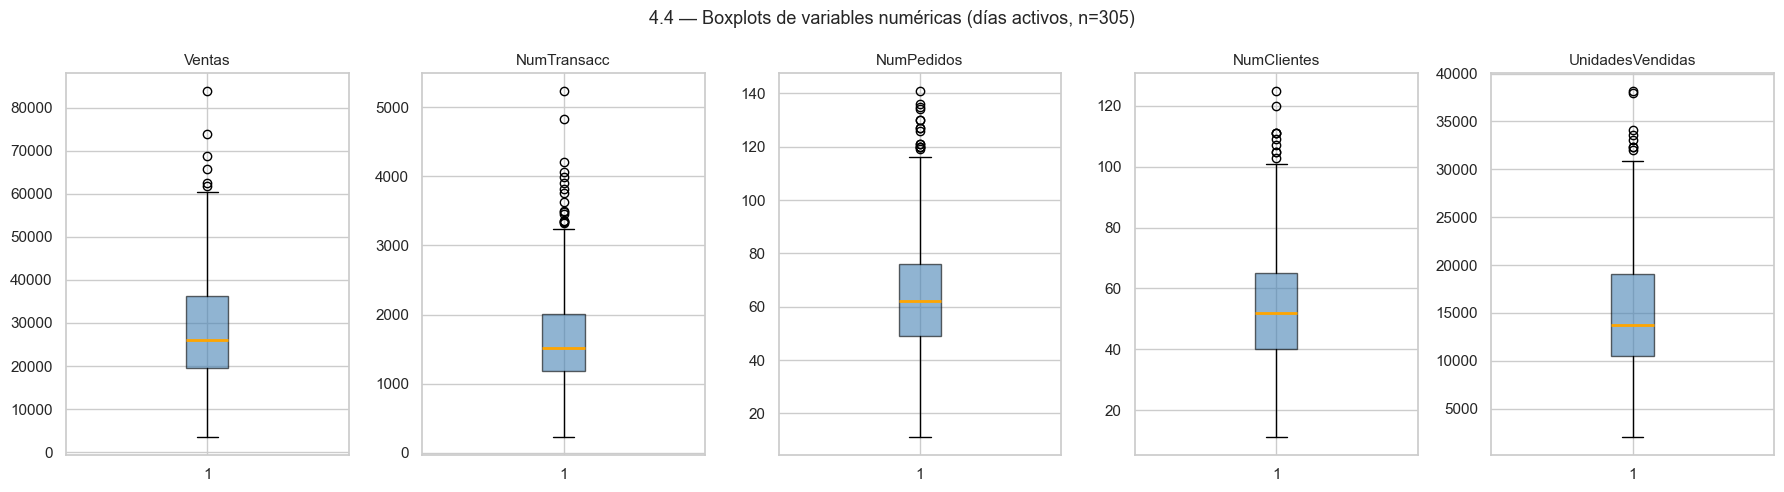

In [127]:
# 4.4.2 — Boxplots de variables numéricas
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(cols_numericas):
    axes[i].boxplot(df_activos[col].values, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='orange', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('')
fig.suptitle(f'4.4 — Boxplots de variables numéricas (días activos, n={len(df_activos)})',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}4.4_boxplots_variables_diarias.png', dpi=150)
plt.show()


In [128]:
# 4.4.3 — Verificar rangos de variables temporales
print("  -- 4.4.3 Verificación de rangos en variables temporales --")
rangos_esperados = {
    'DiaSemana':     (0, 6),
    'EsFinDeSemana': (0, 1),
    'Mes':           (1, 12),
    'Trimestre':     (1, 4),
    'SemanaMes':     (1, 5),
    'DiaAnio':       (1, 366),
    'SemanaAnio':    (1, 53),
}
todo_ok = True
for col, (min_esp, max_esp) in rangos_esperados.items():
    min_real = int(df_daily[col].min())
    max_real = int(df_daily[col].max())
    ok = min_real >= min_esp and max_real <= max_esp
    estado = '✓' if ok else '✗ FUERA DE RANGO'
    if not ok:
        todo_ok = False
    print(f"  {col:<16}: esperado [{min_esp:>3}, {max_esp:>3}]  →  real [{min_real:>3}, {max_real:>3}]  {estado}")
print(f"\n  {'✓ Todas las variables temporales dentro de rango esperado.' if todo_ok else '✗ Revisar columnas marcadas.'}")


  -- 4.4.3 Verificación de rangos en variables temporales --
  DiaSemana       : esperado [  0,   6]  →  real [  0,   6]  ✓
  EsFinDeSemana   : esperado [  0,   1]  →  real [  0,   1]  ✓
  Mes             : esperado [  1,  12]  →  real [  1,  12]  ✓
  Trimestre       : esperado [  1,   4]  →  real [  1,   4]  ✓
  SemanaMes       : esperado [  1,   5]  →  real [  1,   5]  ✓
  DiaAnio         : esperado [  1, 366]  →  real [  1, 365]  ✓
  SemanaAnio      : esperado [  1,  53]  →  real [  1,  52]  ✓

  ✓ Todas las variables temporales dentro de rango esperado.


In [129]:
# 4.4.4 — Análisis de variables categóricas
print("  -- 4.4.4 Análisis de variables categóricas --")

print("\n  ProductoTopDia — top 15 más frecuentes:")
freq_prod  = df_daily['ProductoTopDia'].value_counts()
raros_prod = freq_prod[(freq_prod <= 2) & (freq_prod.index != 'Sin_Actividad')]
print(freq_prod.head(15).to_string())
print(f"\n  Productos únicos (excl. Sin_Actividad): "
      f"{(freq_prod.index != 'Sin_Actividad').sum()}")
print(f"  Productos con ≤2 apariciones (raros): {len(raros_prod)}")
if len(raros_prod) > 0:
    print(f"  → Productos raros: {raros_prod.index.tolist()}")

print("\n  PaisTopDia — distribución completa:")
print(df_daily['PaisTopDia'].value_counts().to_string())
n_uk      = (df_daily['PaisTopDia'] == 'United Kingdom').sum()
n_activos = (df_daily['Ventas'] > 0).sum()
print(f"\n  'United Kingdom' domina {n_uk}/{n_activos} días activos "
      f"({n_uk/n_activos*100:.1f}%) → varianza prácticamente nula → se eliminará en 4.6")


  -- 4.4.4 Análisis de variables categóricas --

  ProductoTopDia — top 15 más frecuentes:
ProductoTopDia
Sin_Actividad    69
85099B           40
23084            26
22197            22
84077            14
85123A           13
21212            10
84879            10
23203             8
47566             7
71459             5
22178             5
22086             5
22834             4
20725             4

  Productos únicos (excl. Sin_Actividad): 109
  Productos con ≤2 apariciones (raros): 89
  → Productos raros: ['84946', '22355', '21985', '85099F', '17003', '21080', '22386', '84991', '22659', '23199', '22740', '84978', '22469', '22151', '16259', '22961', '23310', '75049L', '23209', '16045', '21181', '22952', '22065', '22867', '21844', '17012C', '70006', '84826', '22326', '82581', '20717', '21231', '72741', '22189', '21326', '21918', '22969', '20719', '22908', '21731', '21498', '21878', '22616', '22855', '22741', '20718', '85099C', '22294', '85093', '21749', '23077', '21398', '23207', '

In [130]:
# 4.4.5 — Decisión y conclusión sobre el tratamiento de outliers
print("  -- 4.4.5 Decisión sobre tratamiento de outliers --")
print("""
  Análisis realizado:
    · Los outliers en 'Ventas' y métricas de volumen corresponden a días
      de alta actividad real (pico pre-navideño, Black Friday 2011).
      No son errores de datos: el dataset de e-commerce tiene marcada
      estacionalidad en el Q4 (octubre–diciembre).
    · df_daily solo tiene ~374 filas (~305 activos) → eliminar filas
      empeoraría el modelo por pérdida de información crítica.
    · Capear 'Ventas' eliminaría la señal estacional que el modelo
      debe aprender a predecir.
    · Las variables de volumen (NumTransacc, NumPedidos, etc.) son
      proporcionales a Ventas; capear unas y no otras produce
      inconsistencias internas.
    · Las variables temporales están dentro de sus rangos esperados.
    · 'PaisTopDia' se marcará para eliminación en 4.6 (varianza ≈ 0).

  Decisión: NO se aplica capping ni eliminación en df_daily.
    → Los outliers son eventos reales que forman parte del patrón
      temporal que el modelo debe aprender.
    → Las ventanas rolling (4.8) y lags (4.7) incorporarán el contexto
      histórico y suavizarán la señal para el modelo.
""")
print(f"  ✓ df_daily sin cambios estructurales: {len(df_daily)} filas, "
      f"{len(df_daily.columns)} columnas.")


  -- 4.4.5 Decisión sobre tratamiento de outliers --

  Análisis realizado:
    · Los outliers en 'Ventas' y métricas de volumen corresponden a días
      de alta actividad real (pico pre-navideño, Black Friday 2011).
      No son errores de datos: el dataset de e-commerce tiene marcada
      estacionalidad en el Q4 (octubre–diciembre).
    · df_daily solo tiene ~374 filas (~305 activos) → eliminar filas
      empeoraría el modelo por pérdida de información crítica.
    · Capear 'Ventas' eliminaría la señal estacional que el modelo
      debe aprender a predecir.
    · Las variables de volumen (NumTransacc, NumPedidos, etc.) son
      proporcionales a Ventas; capear unas y no otras produce
      inconsistencias internas.
    · Las variables temporales están dentro de sus rangos esperados.
    · 'PaisTopDia' se marcará para eliminación en 4.6 (varianza ≈ 0).

  Decisión: NO se aplica capping ni eliminación en df_daily.
    → Los outliers son eventos reales que forman parte del patrón
  

### 4.5 Análisis de correlación y selección de variables

Antes de crear los lags y medias móviles analizamos qué variables tienen relación estadística con `Ventas` y detectamos redundancias entre ellas:

- **4.5.1** Correlación de Pearson de todas las variables numéricas con `Ventas`
- **4.5.2** Correlación de Spearman (más robusta ante outliers) — comparativa con Pearson
- **4.5.3** Heatmap de la matriz de correlación completa
- **4.5.4** Análisis de variables categóricas vs `Ventas`
- **4.5.5** Multicolinealidad entre variables de volumen
- **4.5.6** Decisión de variables a eliminar


In [131]:
# 4.5.1 — Correlación de Pearson con 'Ventas'
print("── 4.5 Análisis de correlación y selección de variables ──")
print("\n  -- 4.5.1 Correlación de Pearson con 'Ventas' (variables numéricas) --")
print("  Nota: se usan todos los días completos (incluye ceros de días inactivos)\n")

cols_correlacion = [
    'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas',
    'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre',
    'SemanaMes', 'DiaAnio', 'SemanaAnio'
]

correlaciones = (
    df_daily[cols_correlacion + ['Ventas']]
    .corr()['Ventas']
    .drop('Ventas')
    .sort_values(key=abs, ascending=False)
)

print(f"  {'Variable':<20} {'Correlación':>12}  {'Interpretación'}")
print(f"  {'-'*60}")
for var, corr in correlaciones.items():
    if abs(corr) >= 0.5:
        nivel = 'Alta'
    elif abs(corr) >= 0.3:
        nivel = 'Moderada'
    elif abs(corr) >= 0.1:
        nivel = 'Baja'
    else:
        nivel = 'Muy baja / irrelevante'
    print(f"  {var:<20} {corr:>12.4f}  {nivel}")


── 4.5 Análisis de correlación y selección de variables ──

  -- 4.5.1 Correlación de Pearson con 'Ventas' (variables numéricas) --
  Nota: se usan todos los días completos (incluye ceros de días inactivos)

  Variable              Correlación  Interpretación
  ------------------------------------------------------------
  UnidadesVendidas           0.9731  Alta
  NumPedidos                 0.9112  Alta
  NumTransacc                0.9072  Alta
  NumClientes                0.8923  Alta
  EsFinDeSemana             -0.6079  Alta
  DiaSemana                 -0.4582  Moderada
  Mes                        0.3500  Moderada
  DiaAnio                    0.3434  Moderada
  Trimestre                  0.3410  Moderada
  SemanaAnio                 0.3273  Moderada
  SemanaMes                 -0.0974  Muy baja / irrelevante


In [132]:
# 4.5.2 — Correlación de Spearman (más robusta ante outliers)
print("  -- 4.5.2 Correlación de Spearman con 'Ventas' (más robusta ante outliers) --\n")

correlaciones_sp = (
    df_daily[cols_correlacion + ['Ventas']]
    .corr(method='spearman')['Ventas']
    .drop('Ventas')
    .sort_values(key=abs, ascending=False)
)

print(f"  {'Variable':<20} {'Pearson':>10} {'Spearman':>10}  {'Δ (abs)':>8}")
print(f"  {'-'*55}")
for var in correlaciones_sp.index:
    p  = correlaciones[var] if var in correlaciones.index else float('nan')
    sp = correlaciones_sp[var]
    print(f"  {var:<20} {p:>10.4f} {sp:>10.4f}  {abs(abs(sp)-abs(p)):>8.4f}")


  -- 4.5.2 Correlación de Spearman con 'Ventas' (más robusta ante outliers) --

  Variable                Pearson   Spearman   Δ (abs)
  -------------------------------------------------------
  UnidadesVendidas         0.9731     0.9747    0.0016
  NumTransacc              0.9072     0.9165    0.0093
  NumPedidos               0.9112     0.9115    0.0003
  NumClientes              0.8923     0.8776    0.0146
  EsFinDeSemana           -0.6079    -0.6206    0.0126
  DiaSemana               -0.4582    -0.4630    0.0048
  Mes                      0.3500     0.3346    0.0154
  Trimestre                0.3410     0.3288    0.0121
  DiaAnio                  0.3434     0.3259    0.0175
  SemanaAnio               0.3273     0.3089    0.0184
  SemanaMes               -0.0974    -0.0922    0.0052


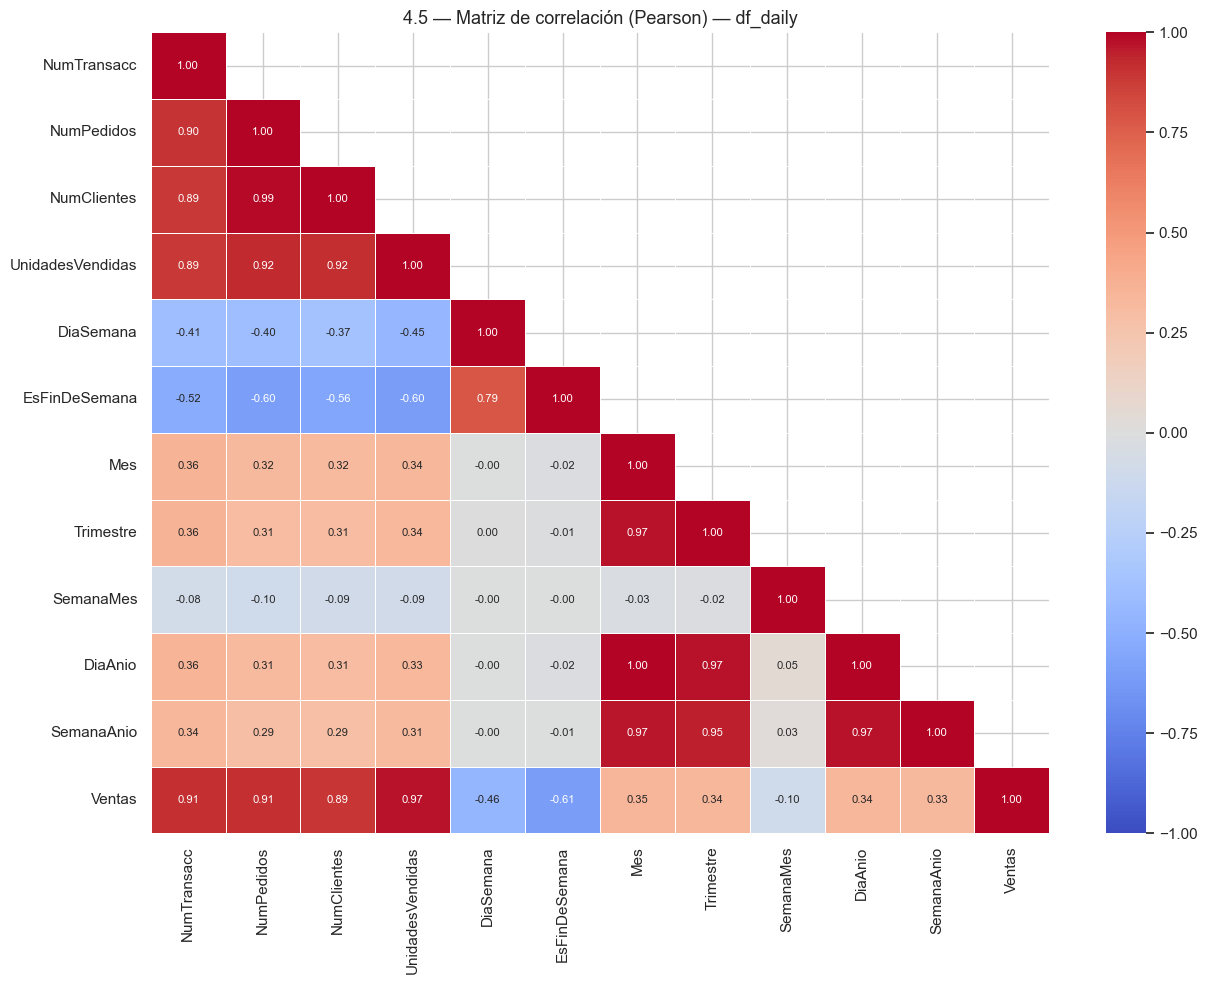

In [133]:
# 4.5.3 — Heatmap de correlaciones
cols_heatmap = cols_correlacion + ['Ventas']
corr_matrix  = df_daily[cols_heatmap].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mascara,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('4.5 — Matriz de correlación (Pearson) — df_daily', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}4.5_correlacion_heatmap.png', dpi=150)
plt.show()


In [134]:
# 4.5.4 — Análisis de variables categóricas vs Ventas
print("  -- 4.5.4 Varianza de PaisTopDia y ProductoTopDia vs Ventas --")

var_pais = df_daily['PaisTopDia'].nunique()
print(f"\n  PaisTopDia: {var_pais} valores únicos → varianza ≈ 0 → candidata a eliminar")

print(f"\n  Ventas media por ProductoTopDia (top 10 más frecuentes):")
media_prod = (
    df_daily[df_daily['ProductoTopDia'] != 'Sin_Actividad']
    .groupby('ProductoTopDia')['Ventas']
    .agg(['mean', 'count'])
    .sort_values('count', ascending=False)
    .head(10)
    .rename(columns={'mean': 'Ventas_Media', 'count': 'N_dias'})
)
print(media_prod.to_string())


  -- 4.5.4 Varianza de PaisTopDia y ProductoTopDia vs Ventas --

  PaisTopDia: 2 valores únicos → varianza ≈ 0 → candidata a eliminar

  Ventas media por ProductoTopDia (top 10 más frecuentes):
                Ventas_Media  N_dias
ProductoTopDia                      
85099B          31246.797000      40
23084           45267.575000      26
22197           33853.187273      22
84077           26337.017857      14
85123A          24570.100769      13
21212           32525.915000      10
84879           25316.220000      10
23203           26885.815000       8
47566           28942.911429       7
71459           22207.328000       5


In [135]:
# 4.5.5 — Multicolinealidad entre variables de volumen
print("  -- 4.5.5 Multicolinealidad entre variables de volumen --")
cols_volumen = ['NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas']
corr_vol = df_daily[cols_volumen].corr().round(3)
print(f"\n  Matriz de correlación entre variables de volumen:")
print(corr_vol.to_string())
print(f"\n  Nota: correlaciones muy altas (>0.95) indican redundancia.")


  -- 4.5.5 Multicolinealidad entre variables de volumen --

  Matriz de correlación entre variables de volumen:
                  NumTransacc  NumPedidos  NumClientes  UnidadesVendidas
NumTransacc             1.000       0.902        0.890             0.890
NumPedidos              0.902       1.000        0.989             0.925
NumClientes             0.890       0.989        1.000             0.919
UnidadesVendidas        0.890       0.925        0.919             1.000

  Nota: correlaciones muy altas (>0.95) indican redundancia.


In [136]:
# 4.5.6 — Decisión y variables descartadas
print("  -- 4.5.6 Decisión de selección de variables --")

VARS_ELIMINAR = ['PaisTopDia']

print(f"""
  Variables ELIMINADAS de df_daily:
    · PaisTopDia        → UK domina ~100% de días activos; varianza ≈ 0;
                          no aporta información al modelo.

  Variables CONSERVADAS con observaciones:
    · NumTransacc, NumPedidos, NumClientes, UnidadesVendidas
                        → Alta correlación con Ventas. Son redundantes entre sí
                          (multicolinealidad alta), pero se conservan todas ahora
                          y se dejará que los modelos con regularización (Ridge,
                          Lasso) las gestionen en la fase de modelado.
    · DiaAnio, SemanaAnio, Mes, Trimestre
                        → Capturan la tendencia y estacionalidad anual.
    · DiaSemana, EsFinDeSemana
                        → Capturan el patrón semanal (fines de semana = 0 ventas).
    · SemanaMes         → Correlación baja; se conserva por si aporta
                          señal en combinación con otras variables.
    · ProductoTopDia    → Se conserva; el encoding se hará en el bloque
                          de codificación (agrupando raros en 'Otros').
""")

df_daily = df_daily.drop(columns=VARS_ELIMINAR)
stats_preprocesing['Variables eliminadas (baja varianza)'] = VARS_ELIMINAR

print(f"  Columnas finales en df_daily ({len(df_daily.columns)} total):")
print(f"  {list(df_daily.columns)}")
print(f"\n  ✓ Selección de variables completada. df_daily listo para lags y rolling windows.")


  -- 4.5.6 Decisión de selección de variables --

  Variables ELIMINADAS de df_daily:
    · PaisTopDia        → UK domina ~100% de días activos; varianza ≈ 0;
                          no aporta información al modelo.

  Variables CONSERVADAS con observaciones:
    · NumTransacc, NumPedidos, NumClientes, UnidadesVendidas
                        → Alta correlación con Ventas. Son redundantes entre sí
                          (multicolinealidad alta), pero se conservan todas ahora
                          y se dejará que los modelos con regularización (Ridge,
                          Lasso) las gestionen en la fase de modelado.
    · DiaAnio, SemanaAnio, Mes, Trimestre
                        → Capturan la tendencia y estacionalidad anual.
    · DiaSemana, EsFinDeSemana
                        → Capturan el patrón semanal (fines de semana = 0 ventas).
    · SemanaMes         → Correlación baja; se conserva por si aporta
                          señal en combinación con otras variable

### 4.6 Lags (retrasos temporales)

Los **lags** permiten al modelo usar las ventas de días anteriores como predictores del día actual, capturando la autocorrelación de la serie temporal:

| Variable | Descripción |
|---|---|
| `Ventas_Lag1` | Ventas del día anterior (t-1) |
| `Ventas_Lag7` | Ventas del mismo día de la semana pasada (t-7) |

Tras crear los lags se eliminan las primeras 7 filas (las únicas que tienen NaN) antes de calcular las medias móviles. Esto es correcto porque las medias móviles usan `min_periods=1` y no generan NaN adicionales, por lo que no tiene sentido retrasar el `dropna()`.


In [137]:
# 4.6 — Lags (retrasos temporales)
print("── 4.6 Lags (retrasos temporales) ──")

df_daily['Ventas_Lag1'] = df_daily['Ventas'].shift(1)
df_daily['Ventas_Lag7'] = df_daily['Ventas'].shift(7)

n_nan_lag1 = df_daily['Ventas_Lag1'].isna().sum()
n_nan_lag7 = df_daily['Ventas_Lag7'].isna().sum()

print(f"\n  Lag1 — NaN generados: {n_nan_lag1}  (fila 0: sin día anterior)")
print(f"  Lag7 — NaN generados: {n_nan_lag7}  (filas 0–6: sin semana anterior)")

print(f"\n  Primeras 10 filas con lags (observar NaN iniciales):")
cols_lag = ['Fecha', 'Ventas', 'Ventas_Lag1', 'Ventas_Lag7']
print(df_daily[cols_lag].head(10).to_string(index=False))

# ── Eliminar las primeras 7 filas con NaN — antes de las rolling windows ──────
filas_antes = len(df_daily)
df_daily = df_daily.dropna(subset=['Ventas_Lag1', 'Ventas_Lag7']).reset_index(drop=True)
filas_despues = len(df_daily)

print(f"\n  Filas antes del dropna : {filas_antes}")
print(f"  Filas eliminadas       : {filas_antes - filas_despues}  "
      f"(primera fila válida: {df_daily['Fecha'].min().date()})")
print(f"  Filas tras el dropna   : {filas_despues}")

stats_preprocesing['Filas eliminadas por lags (NaN iniciales)'] = filas_antes - filas_despues


── 4.6 Lags (retrasos temporales) ──

  Lag1 — NaN generados: 1  (fila 0: sin día anterior)
  Lag7 — NaN generados: 7  (filas 0–6: sin semana anterior)

  Primeras 10 filas con lags (observar NaN iniciales):
     Fecha   Ventas  Ventas_Lag1  Ventas_Lag7
2010-12-01 51118.57          NaN          NaN
2010-12-02 40795.79     51118.57          NaN
2010-12-03 41801.33     40795.79          NaN
2010-12-04     0.00     41801.33          NaN
2010-12-05 29650.64         0.00          NaN
2010-12-06 47492.93     29650.64          NaN
2010-12-07 57696.38     47492.93          NaN
2010-12-08 40935.64     57696.38     51118.57
2010-12-09 43420.95     40935.64     40795.79
2010-12-10 50741.62     43420.95     41801.33

  Filas antes del dropna : 374
  Filas eliminadas       : 7  (primera fila válida: 2010-12-08)
  Filas tras el dropna   : 367


In [138]:
# 4.6 — Validación de consistencia de los lags
print("  Validación — muestra de consistencia (Ventas_Lag1):")
idx_check = [10, 20, 50]
for i in idx_check:
    fecha_actual  = df_daily.loc[i, 'Fecha']
    ventas_actual = df_daily.loc[i, 'Ventas']
    lag1_almac    = df_daily.loc[i, 'Ventas_Lag1']
    ventas_ayer   = df_daily.loc[i - 1, 'Ventas']
    ok = '✓' if abs(lag1_almac - ventas_ayer) < 0.01 else '✗'
    print(f"  [{i}] {fecha_actual.date()}  Ventas={ventas_actual:>10,.2f}"
          f"  Lag1={lag1_almac:>10,.2f}  Ventas[i-1]={ventas_ayer:>10,.2f}  {ok}")

print(f"\n  Estadísticas de los lags:")
print(df_daily[['Ventas_Lag1', 'Ventas_Lag7']].describe()
      .map(lambda x: f"{x:>12,.2f}").to_string())

print(f"\n  Columnas en df_daily ({len(df_daily.columns)} total): {list(df_daily.columns)}")
print(f"\n  ✓ Lags añadidos. df_daily: {len(df_daily)} filas.")


  Validación — muestra de consistencia (Ventas_Lag1):
  [10] 2010-12-18  Ventas=      0.00  Lag1= 38,388.04  Ventas[i-1]= 38,388.04  ✓
  [20] 2010-12-28  Ventas=      0.00  Lag1=      0.00  Ventas[i-1]=      0.00  ✓
  [50] 2011-01-27  Ventas= 22,091.53  Lag1= 17,748.27  Ventas[i-1]= 17,748.27  ✓

  Estadísticas de los lags:
        Ventas_Lag1   Ventas_Lag7
count        367.00        367.00
mean      23,119.74     22,963.19
std       16,673.51     16,337.16
min            0.00          0.00
25%       11,034.26     11,034.26
50%       22,592.35     22,592.35
75%       32,536.19     32,536.19
max       83,931.62     83,931.62

  Columnas en df_daily (16 total): ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7']

  ✓ Lags añadidos. df_daily: 367 filas.


### 4.7 Medias móviles (rolling windows)

Las medias móviles suavizan los picos aislados y capturan la tendencia reciente:

| Variable | Cálculo | Descripción |
|---|---|---|
| `Ventas_Media_7d` | `shift(1).rolling(7).mean()` | Media de los 7 días **anteriores** al día t |
| `Ventas_Media_30d` | `shift(1).rolling(30).mean()` | Media de los 30 días **anteriores** al día t |

El `shift(1)` **antes** del `rolling` es crítico para evitar **data leakage**: sin él, la media del día t incluiría las ventas del propio día t, que es exactamente lo que el modelo tiene que predecir. Con `shift(1)` la ventana siempre termina en t-1.

`min_periods=1` permite calcular la media aunque no haya 7 o 30 días previos completos (inicio de la serie), evitando NaN adicionales.


In [139]:
# 4.7 — Medias móviles con shift(1) para evitar data leakage
print("── 4.7 Medias móviles (rolling windows) ──")

# shift(1) ANTES del rolling → la ventana usa solo días anteriores a t, nunca t
df_daily['Ventas_Media_7d']  = df_daily['Ventas'].shift(1).rolling(window=7,  min_periods=1).mean()
df_daily['Ventas_Media_30d'] = df_daily['Ventas'].shift(1).rolling(window=30, min_periods=1).mean()

n_nan_7d  = df_daily['Ventas_Media_7d'].isna().sum()
n_nan_30d = df_daily['Ventas_Media_30d'].isna().sum()
print(f"\n  NaN en Ventas_Media_7d  : {n_nan_7d}   (esperado: 0 con min_periods=1)")
print(f"  NaN en Ventas_Media_30d : {n_nan_30d}  (esperado: 0 con min_periods=1)")

print(f"\n  Primeras 12 filas con medias móviles:")
cols_roll = ['Fecha', 'Ventas', 'Ventas_Media_7d', 'Ventas_Media_30d']
print(df_daily[cols_roll].head(12).to_string(index=False))


── 4.7 Medias móviles (rolling windows) ──

  NaN en Ventas_Media_7d  : 1   (esperado: 0 con min_periods=1)
  NaN en Ventas_Media_30d : 1  (esperado: 0 con min_periods=1)

  Primeras 12 filas con medias móviles:
     Fecha   Ventas  Ventas_Media_7d  Ventas_Media_30d
2010-12-08 40935.64              NaN               NaN
2010-12-09 43420.95     40935.640000      40935.640000
2010-12-10 50741.62     42178.295000      42178.295000
2010-12-11     0.00     45032.736667      45032.736667
2010-12-12 16751.70     33774.552500      33774.552500
2010-12-13 34693.15     30369.982000      30369.982000
2010-12-14 40153.95     31090.510000      31090.510000
2010-12-15 26630.96     32385.287143      32385.287143
2010-12-16 38464.87     30341.761429      31665.996250
2010-12-17 38388.04     29633.750000      32421.426667
2010-12-18     0.00     27868.952857      33018.088000
2010-12-19  7034.15     27868.952857      30016.443636


In [140]:
# 4.7 — Validación manual: fila i debe tener Media_7d = media de Ventas[i-7 … i-1]
print("  Validación manual de Ventas_Media_7d en fila 10:")
media_manual = df_daily.loc[3:9, 'Ventas'].mean()   # filas i-7 a i-1  (shift + rolling 7)
media_stored = df_daily.loc[10, 'Ventas_Media_7d']
ok = '✓' if abs(media_manual - media_stored) < 0.01 else '✗'
print(f"  Media manual Ventas[3–9]: {media_manual:>12,.2f}")
print(f"  Valor almacenado [10]   : {media_stored:>12,.2f}  {ok}")

print(f"\n  Estadísticas de las medias móviles:")
print(df_daily[['Ventas_Media_7d', 'Ventas_Media_30d']].describe()
      .map(lambda x: f"{x:>12,.2f}").to_string())

stats_preprocesing['Medias móviles añadidas'] = ['Ventas_Media_7d (shift-1)', 'Ventas_Media_30d (shift-1)']


  Validación manual de Ventas_Media_7d en fila 10:
  Media manual Ventas[3–9]:    27,868.95
  Valor almacenado [10]   :    27,868.95  ✓

  Estadísticas de las medias móviles:
      Ventas_Media_7d Ventas_Media_30d
count          366.00           366.00
mean        22,904.83        22,476.80
std          9,394.71         7,568.70
min              0.00        11,085.42
25%         16,895.87        17,460.88
50%         20,755.61        19,942.52
75%         28,293.65        25,602.13
max         48,502.20        45,032.74


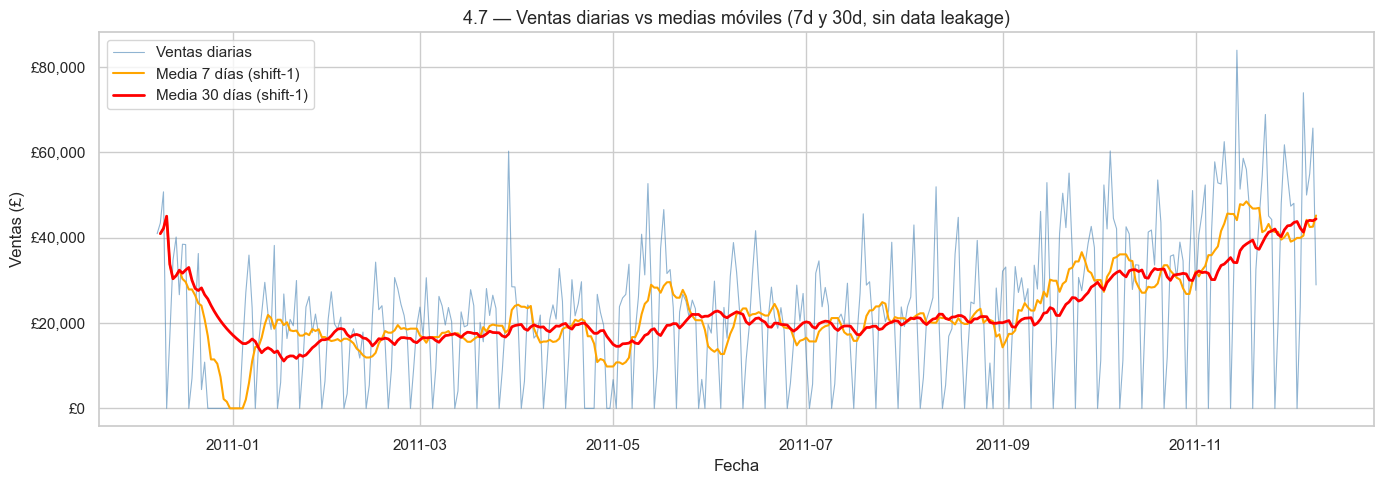


  Columnas en df_daily (18 total): ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d']

  ✓ Medias móviles añadidas. df_daily: 367 filas.


In [141]:
# 4.7 — Gráfica: Ventas vs medias móviles
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_daily['Fecha'], df_daily['Ventas'],
        color='steelblue', linewidth=0.8, alpha=0.6, label='Ventas diarias')
ax.plot(df_daily['Fecha'], df_daily['Ventas_Media_7d'],
        color='orange', linewidth=1.5, label='Media 7 días (shift-1)')
ax.plot(df_daily['Fecha'], df_daily['Ventas_Media_30d'],
        color='red', linewidth=2.0, label='Media 30 días (shift-1)')
ax.set_title('4.7 — Ventas diarias vs medias móviles (7d y 30d, sin data leakage)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}4.7_medias_moviles.png', dpi=150)
plt.show()

print(f"\n  Columnas en df_daily ({len(df_daily.columns)} total): {list(df_daily.columns)}")
print(f"\n  ✓ Medias móviles añadidas. df_daily: {len(df_daily)} filas.")


### 4.8 Eventos especiales

El e-commerce tiene un fuerte pico de ventas en el período pre-navideño. Se crean dos variables para capturar esta estacionalidad:

| Variable | Rango | Descripción |
|---|---|---|
| `Es_Navidad` | 0–1 | 1 si la fecha está entre el 20 y el 25 de diciembre |
| `Dias_para_Navidad` | 0–30 | Días que faltan para el 25 de diciembre (ventana de 30 días previos; 0 fuera de ese rango) |

`Dias_para_Navidad` aporta una señal cuantitativa de la proximidad al pico: el modelo puede aprender que las ventas aumentan gradualmente a medida que se acerca la fecha.


In [142]:
# 4.8 — Eventos especiales
print("── 4.8 Eventos especiales ──")

# Variable binaria: período navideño (20–25 diciembre)
df_daily['Es_Navidad'] = (
    (df_daily['Fecha'].dt.month == 12) &
    (df_daily['Fecha'].dt.day.between(20, 25))
).astype(int)

dias_navidad = df_daily['Es_Navidad'].sum()
print(f"\n  Es_Navidad — días marcados: {dias_navidad}")
print(df_daily.loc[df_daily['Es_Navidad'] == 1,
                   ['Fecha', 'Ventas', 'Es_Navidad']].to_string(index=False))

# Variable cuantitativa: días que faltan para Navidad (ventana 30 días)
NAV_VENTANA = 30

def dias_para_navidad(fecha):
    navidad = pd.Timestamp(fecha.year, 12, 25)
    delta   = (navidad - fecha).days
    return delta if 0 < delta <= NAV_VENTANA else 0

df_daily['Dias_para_Navidad'] = df_daily['Fecha'].apply(dias_para_navidad)

print(f"\n  Dias_para_Navidad — distribución de valores > 0:")
print(df_daily.loc[df_daily['Dias_para_Navidad'] > 0,
                   ['Fecha', 'Ventas', 'Dias_para_Navidad']]
      .sort_values('Fecha').to_string(index=False))

stats_preprocesing['Variables de eventos añadidas'] = ['Es_Navidad', 'Dias_para_Navidad']


── 4.8 Eventos especiales ──

  Es_Navidad — días marcados: 6
     Fecha   Ventas  Es_Navidad
2010-12-20 21706.32           1
2010-12-21 36287.29           1
2010-12-22  4394.97           1
2010-12-23 10828.34           1
2010-12-24     0.00           1
2010-12-25     0.00           1

  Dias_para_Navidad — distribución de valores > 0:
     Fecha   Ventas  Dias_para_Navidad
2010-12-08 40935.64                 17
2010-12-09 43420.95                 16
2010-12-10 50741.62                 15
2010-12-11     0.00                 14
2010-12-12 16751.70                 13
2010-12-13 34693.15                 12
2010-12-14 40153.95                 11
2010-12-15 26630.96                 10
2010-12-16 38464.87                  9
2010-12-17 38388.04                  8
2010-12-18     0.00                  7
2010-12-19  7034.15                  6
2010-12-20 21706.32                  5
2010-12-21 36287.29                  4
2010-12-22  4394.97                  3
2010-12-23 10828.34                  2

In [143]:
# 4.8 — Verificación de rangos
assert df_daily['Es_Navidad'].isin([0, 1]).all(), \
    "ERROR: Es_Navidad contiene valores fuera de {0, 1}"
assert df_daily['Dias_para_Navidad'].between(0, NAV_VENTANA).all(), \
    f"ERROR: Dias_para_Navidad fuera del rango [0, {NAV_VENTANA}]"

print(f"  Verificación de rangos:")
print(f"  Es_Navidad        : valores únicos → {sorted(df_daily['Es_Navidad'].unique())}  ✓")
print(f"  Dias_para_Navidad : rango [{df_daily['Dias_para_Navidad'].min()}, "
      f"{df_daily['Dias_para_Navidad'].max()}]  (esperado [0, {NAV_VENTANA}])  ✓")
print(f"\n  Columnas finales en df_daily ({len(df_daily.columns)} total):")
print(f"  {list(df_daily.columns)}")
print(f"  Filas: {len(df_daily)}")


  Verificación de rangos:
  Es_Navidad        : valores únicos → [np.int64(0), np.int64(1)]  ✓
  Dias_para_Navidad : rango [0, 30]  (esperado [0, 30])  ✓

  Columnas finales en df_daily (20 total):
  ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'Es_Navidad', 'Dias_para_Navidad']
  Filas: 367


In [144]:
# ── 4.9  Guardar df_daily en interim ─────────────────────────────────────────
df_daily.to_csv(RUTA_INTERIM + 'data_daily.csv', index=False)
stats_preprocesing['df_daily guardado en'] = RUTA_INTERIM + 'data_daily.csv'

print(f"  ✓ df_daily guardado en: {RUTA_INTERIM}data_daily.csv")
print(f"    Filas:    {len(df_daily)}")
print(f"    Columnas: {len(df_daily.columns)}")
print(f"    Columnas: {list(df_daily.columns)}")
print(f"\n  ✓ Sección 4 (Transformación) completada.")


  ✓ df_daily guardado en: ../../../data/interim/data_daily.csv
    Filas:    367
    Columnas: 20
    Columnas: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'Es_Navidad', 'Dias_para_Navidad']

  ✓ Sección 4 (Transformación) completada.


# 5.  ENCODING DE VARIABLES CATEGÓRICAS

| Sub-sección | Acción | Método |
|---|---|---|
| 5.1 | Inventario de columnas | Clasificación por tipo |
| 5.2 | Prueba sklearn | LabelEncoder vs OHE vs cíclico |
| 5.3 | Encoding cíclico | sin/cos para DiaSemana y Mes |
| 5.4 | Agrupación de raros | ProductoTopDia → "Otros" |
| 5.5 | OHE sklearn | OneHotEncoder para ProductoTopDia |
| 5.6 | Resumen y guardado | df_encoded → data_encoded.csv |


### 5.1  INVENTARIO DE COLUMNAS — CLASIFICACIÓN POR TIPO DE ENCODING


In [145]:
print("\n\n=== 5. ENCODING DE VARIABLES CATEGÓRICAS ===")
print("\n--- 5.1 Inventario: clasificación por tipo de encoding ---\n")

cols_numericas_enc = [
    'Ventas',            # variable objetivo — sin cambio
    'NumTransacc',       # volumen — numérica continua
    'NumPedidos',        # volumen — numérica continua
    'NumClientes',       # volumen — numérica continua
    'UnidadesVendidas',  # volumen — numérica continua
    'Trimestre',         # ordinal numérica (1–4)
    'SemanaMes',         # ordinal numérica (1–5)
    'DiaAnio',           # ordinal numérica (1–365)
    'SemanaAnio',        # ordinal numérica (1–52)
    'EsFinDeSemana',     # binaria (0/1) — ya codificada
    'Es_Navidad',        # binaria (0/1) — ya codificada
    'Dias_para_Navidad', # numérica discreta (0–30)
    'Ventas_Lag1',       # lag numérico
    'Ventas_Lag7',       # lag numérico
    'Ventas_Media_7d',   # rolling numérico
    'Ventas_Media_30d',  # rolling numérico
]

cols_ciclicas_enc = {
    'DiaSemana': 7,   # período 7  → sin/cos
    'Mes':       12,  # período 12 → sin/cos
}

cols_ohe = [
    'ProductoTopDia',  # nominal, ~22 cats tras agrupar raros
]

# ── Verificación: todas las columnas de df_daily (excl. Fecha) clasificadas ──
cols_clasificadas = set(cols_numericas_enc) | set(cols_ciclicas_enc.keys()) | set(cols_ohe)
cols_df  = set(df_daily.columns) - {'Fecha'}
cols_sin = cols_df - cols_clasificadas
cols_ext = cols_clasificadas - cols_df

print("  COLUMNAS NUMÉRICAS (sin cambio):")
for c in cols_numericas_enc:
    print(f"    · {c:<22} dtype={df_daily[c].dtype}")

print("\n  COLUMNAS CÍCLICAS (→ sin/cos):")
for c, periodo in cols_ciclicas_enc.items():
    rango = f"[{df_daily[c].min():.0f}, {df_daily[c].max():.0f}]"
    print(f"    · {c:<22} período={periodo}  rango={rango}")

print("\n  COLUMNAS NOMINALES (→ OHE):")
for c in cols_ohe:
    print(f"    · {c:<22} categorías únicas={df_daily[c].nunique()}")

if cols_sin:
    print(f"\n  ⚠ Columnas sin clasificar: {cols_sin}")
else:
    print("\n  ✓ Todas las columnas clasificadas correctamente.")

print(f"\n  Resumen:")
print(f"    Numéricas (sin cambio) : {len(cols_numericas_enc)}")
print(f"    Cíclicas  (sin/cos)    : {len(cols_ciclicas_enc)}")
print(f"    Nominales (OHE)        : {len(cols_ohe)}")
print(f"    Fecha                  :  1  (índice temporal — no se codifica)")
print(f"    Total columnas df_daily: {len(df_daily.columns)}")
print("\n  ✓ Inventario completado.")




=== 5. ENCODING DE VARIABLES CATEGÓRICAS ===

--- 5.1 Inventario: clasificación por tipo de encoding ---

  COLUMNAS NUMÉRICAS (sin cambio):
    · Ventas                 dtype=float64
    · NumTransacc            dtype=float64
    · NumPedidos             dtype=float64
    · NumClientes            dtype=float64
    · UnidadesVendidas       dtype=float64
    · Trimestre              dtype=int32
    · SemanaMes              dtype=int64
    · DiaAnio                dtype=int32
    · SemanaAnio             dtype=int64
    · EsFinDeSemana          dtype=int64
    · Es_Navidad             dtype=int64
    · Dias_para_Navidad      dtype=int64
    · Ventas_Lag1            dtype=float64
    · Ventas_Lag7            dtype=float64
    · Ventas_Media_7d        dtype=float64
    · Ventas_Media_30d       dtype=float64

  COLUMNAS CÍCLICAS (→ sin/cos):
    · DiaSemana              período=7  rango=[0, 6]
    · Mes                    período=12  rango=[1, 12]

  COLUMNAS NOMINALES (→ OHE):
    · Prod

### 5.2  PRUEBA SKLEARN: LabelEncoder vs OHE vs Cíclico en DiaSemana


In [146]:
print("\n--- 5.2 Prueba sklearn: LabelEncoder vs OHE vs Cíclico en DiaSemana ---\n")

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

diasemana_vals = df_daily[['DiaSemana']].copy().reset_index(drop=True)

# ── 5.2.1  LabelEncoder ───────────────────────────────────────────────────────
le = LabelEncoder()
diasemana_vals['LE'] = le.fit_transform(diasemana_vals['DiaSemana'])

print("  5.2.1  LabelEncoder:")
print("  Asigna un entero a cada categoría — mantiene el orden original.")
print(f"  Clases: {list(le.classes_)}  →  valores: {list(range(len(le.classes_)))}")
print("  Problema: implica orden numérico (0<1<2...) y distancias falsas.")
print("  Ejemplo: Lun(0) - Dom(6) = 6, pero realmente son días adyacentes.\n")

# ── 5.2.2  OneHotEncoder ──────────────────────────────────────────────────────
ohe_test = OneHotEncoder(sparse_output=False, drop='first')
ohe_array = ohe_test.fit_transform(diasemana_vals[['DiaSemana']])
ohe_cols = [f'DiaSemana_OHE_{int(c)}' for c in ohe_test.categories_[0][1:]]

print("  5.2.2  OneHotEncoder (drop='first'):")
print(f"  Genera {len(ohe_cols)} columnas binarias — elimina orden falso.")
print(f"  Columnas: {ohe_cols}")
print("  Problema: no captura la CONTINUIDAD cíclica.")
print("  Dom(6) y Lun(0) son días consecutivos pero el modelo los ve como lejanos.\n")

# ── 5.2.3  Codificación cíclica (sin/cos) ────────────────────────────────────
periodo = 7
diasemana_vals['DiaSemana_sin'] = np.sin(2 * np.pi * diasemana_vals['DiaSemana'] / periodo)
diasemana_vals['DiaSemana_cos'] = np.cos(2 * np.pi * diasemana_vals['DiaSemana'] / periodo)

print("  5.2.3  Codificación cíclica (sin/cos):")
print(f"  Fórmula: sin(2π·DiaSemana/7) y cos(2π·DiaSemana/7)")
print(f"  {'DiaSemana':<12} {'sin':>8} {'cos':>8}  Nombre")
dias_nombres = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves',
                4:'Viernes', 5:'Sábado', 6:'Domingo'}
for d in range(7):
    s = np.sin(2 * np.pi * d / periodo)
    c = np.cos(2 * np.pi * d / periodo)
    print(f"  {d:<12} {s:>8.4f} {c:>8.4f}  {dias_nombres[d]}")



--- 5.2 Prueba sklearn: LabelEncoder vs OHE vs Cíclico en DiaSemana ---

  5.2.1  LabelEncoder:
  Asigna un entero a cada categoría — mantiene el orden original.
  Clases: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]  →  valores: [0, 1, 2, 3, 4, 5, 6]
  Problema: implica orden numérico (0<1<2...) y distancias falsas.
  Ejemplo: Lun(0) - Dom(6) = 6, pero realmente son días adyacentes.

  5.2.2  OneHotEncoder (drop='first'):
  Genera 6 columnas binarias — elimina orden falso.
  Columnas: ['DiaSemana_OHE_1', 'DiaSemana_OHE_2', 'DiaSemana_OHE_3', 'DiaSemana_OHE_4', 'DiaSemana_OHE_5', 'DiaSemana_OHE_6']
  Problema: no captura la CONTINUIDAD cíclica.
  Dom(6) y Lun(0) son días consecutivos pero el modelo los ve como lejanos.

  5.2.3  Codificación cíclica (sin/cos):
  Fórmula: sin(2π·DiaSemana/7) y cos(2π·DiaSemana/7)
  DiaSemana         sin      cos  Nombre
  0              0.0000   1.0000  Lunes
  1              0.7818   0.6235  Martes
  2   


  5.2.4  Distancia Lunes(0) ↔ Domingo(6):
    LabelEncoder  Lun↔Dom = 6      (parece muy lejanos)
    Cíclica       Lun↔Dom = 0.8678  (≈ Lun↔Mar = 0.8678) ✓


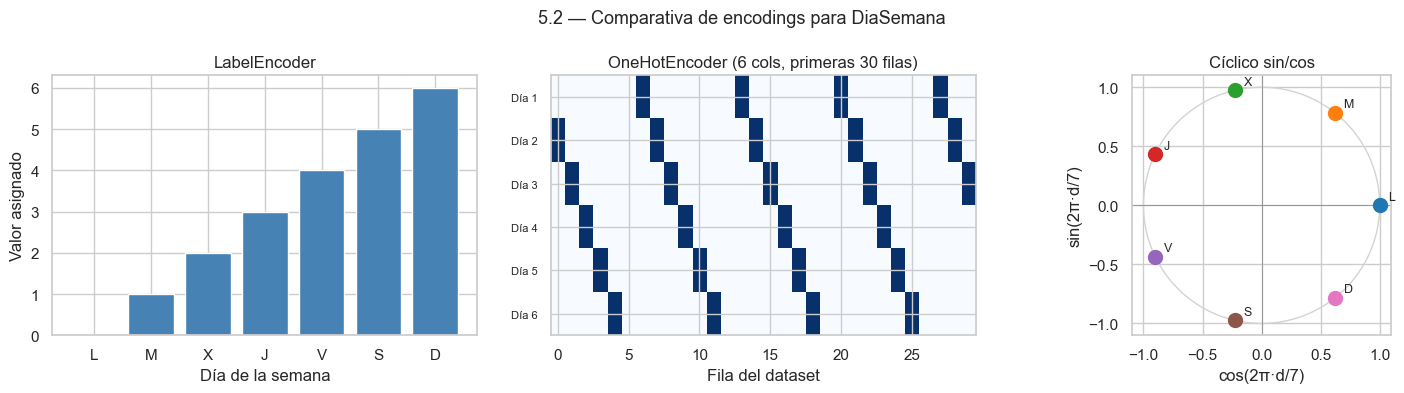


  DECISIÓN:
    · LabelEncoder  → DESCARTADO: orden numérico falso.
    · OneHotEncoder → DESCARTADO: no captura continuidad cíclica.
    · sin/cos       → ELEGIDO: preserva circularidad del calendario.

  ✓ Prueba sklearn completada. Decisión justificada.


In [147]:
# ── 5.2.4  Comparativa de distancias ─────────────────────────────────────────
print("\n  5.2.4  Distancia Lunes(0) ↔ Domingo(6):")
d_label     = abs(6 - 0)
d_ciclica   = np.sqrt((np.sin(2*np.pi*6/7) - np.sin(2*np.pi*0/7))**2 +
                       (np.cos(2*np.pi*6/7) - np.cos(2*np.pi*0/7))**2)
d_adyacente = np.sqrt((np.sin(2*np.pi*1/7) - np.sin(2*np.pi*0/7))**2 +
                       (np.cos(2*np.pi*1/7) - np.cos(2*np.pi*0/7))**2)
print(f"    LabelEncoder  Lun↔Dom = {d_label}      (parece muy lejanos)")
print(f"    Cíclica       Lun↔Dom = {d_ciclica:.4f}  (≈ Lun↔Mar = {d_adyacente:.4f}) ✓")

# ── 5.2.5  Gráfica comparativa ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('5.2 — Comparativa de encodings para DiaSemana', fontsize=13)

axes[0].bar(range(7), range(7), color='steelblue')
axes[0].set_title('LabelEncoder')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['L','M','X','J','V','S','D'])
axes[0].set_ylabel('Valor asignado')
axes[0].set_xlabel('Día de la semana')

axes[1].imshow(ohe_array[:30].T, aspect='auto', cmap='Blues')
axes[1].set_title('OneHotEncoder (6 cols, primeras 30 filas)')
axes[1].set_xlabel('Fila del dataset')
axes[1].set_yticks(range(len(ohe_cols)))
axes[1].set_yticklabels([c.replace('DiaSemana_OHE_','Día ') for c in ohe_cols], fontsize=8)

theta = np.linspace(0, 2*np.pi, 200)
axes[2].plot(np.cos(theta), np.sin(theta), 'lightgray', lw=1)
colors_dias = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']
for d in range(7):
    s = np.sin(2 * np.pi * d / 7)
    c = np.cos(2 * np.pi * d / 7)
    axes[2].scatter(c, s, color=colors_dias[d], s=100, zorder=5)
    axes[2].annotate(list('LMXJVSD')[d], (c, s),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[2].set_title('Cíclico sin/cos')
axes[2].set_aspect('equal')
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].axvline(0, color='gray', lw=0.5)
axes[2].set_xlabel('cos(2π·d/7)')
axes[2].set_ylabel('sin(2π·d/7)')

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}5.2_encoding_comparativa.png', dpi=150)
plt.show()

# ── 5.2.6  Decisión ───────────────────────────────────────────────────────────
print("\n  DECISIÓN:")
print("    · LabelEncoder  → DESCARTADO: orden numérico falso.")
print("    · OneHotEncoder → DESCARTADO: no captura continuidad cíclica.")
print("    · sin/cos       → ELEGIDO: preserva circularidad del calendario.")
print("\n  ✓ Prueba sklearn completada. Decisión justificada.")


### 5.3  ENCODING CÍCLICO DEFINITIVO: DiaSemana y Mes


In [148]:
print("\n--- 5.3 Encoding cíclico (sin/cos) para DiaSemana y Mes ---\n")

# ── 5.3.1  DiaSemana (período 7) ──────────────────────────────────────────────
df_daily['DiaSemana_sin'] = np.sin(2 * np.pi * df_daily['DiaSemana'] / 7)
df_daily['DiaSemana_cos'] = np.cos(2 * np.pi * df_daily['DiaSemana'] / 7)

# ── 5.3.2  Mes (período 12) ───────────────────────────────────────────────────
df_daily['Mes_sin'] = np.sin(2 * np.pi * (df_daily['Mes'] - 1) / 12)
df_daily['Mes_cos'] = np.cos(2 * np.pi * (df_daily['Mes'] - 1) / 12)

# ── 5.3.3  Eliminar columnas originales ───────────────────────────────────────
df_daily = df_daily.drop(columns=['DiaSemana', 'Mes'])

# ── 5.3.4  Verificación ───────────────────────────────────────────────────────
print("  Columnas nuevas creadas:")
for col in ['DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos']:
    nans = df_daily[col].isna().sum()
    vmin = df_daily[col].min()
    vmax = df_daily[col].max()
    print(f"    · {col:<18} rango=[{vmin:>7.4f}, {vmax:>7.4f}]  NaN={nans}  ✓")

assert df_daily['DiaSemana_sin'].between(-1, 1).all(), "ERROR: DiaSemana_sin fuera de [-1,1]"
assert df_daily['DiaSemana_cos'].between(-1, 1).all(), "ERROR: DiaSemana_cos fuera de [-1,1]"
assert df_daily['Mes_sin'].between(-1, 1).all(),       "ERROR: Mes_sin fuera de [-1,1]"
assert df_daily['Mes_cos'].between(-1, 1).all(),       "ERROR: Mes_cos fuera de [-1,1]"

assert 'DiaSemana' not in df_daily.columns, "ERROR: DiaSemana original no eliminada"
assert 'Mes'       not in df_daily.columns, "ERROR: Mes original no eliminada"
print("\n  Columnas originales eliminadas: DiaSemana ✓  Mes ✓")



--- 5.3 Encoding cíclico (sin/cos) para DiaSemana y Mes ---

  Columnas nuevas creadas:
    · DiaSemana_sin      rango=[-0.9749,  0.9749]  NaN=0  ✓
    · DiaSemana_cos      rango=[-0.9010,  1.0000]  NaN=0  ✓
    · Mes_sin            rango=[-1.0000,  1.0000]  NaN=0  ✓
    · Mes_cos            rango=[-1.0000,  1.0000]  NaN=0  ✓

  Columnas originales eliminadas: DiaSemana ✓  Mes ✓


In [149]:
# ── 5.3.5  Verificación manual ────────────────────────────────────────────────
# Lunes (DiaSemana=0): sin≈0, cos≈1
lunes = df_daily[df_daily['DiaSemana_sin'].round(4) == 0.0].iloc[0]
print(f"  Verificación manual — primera fila que era Lunes (DiaSemana=0):")
print(f"    DiaSemana_sin = {lunes['DiaSemana_sin']:.4f}  (esperado ≈ 0.0000) ✓")
print(f"    DiaSemana_cos = {lunes['DiaSemana_cos']:.4f}  (esperado ≈ 1.0000) ✓")

# ── 5.3.6  Primeras filas con los nuevos encodings ────────────────────────────
print(f"\n  Primeras 7 filas con encodings cíclicos:")
cols_show = ['Fecha', 'DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos']
print(df_daily[cols_show].head(7).to_string(index=False,
      float_format=lambda x: f'{x:>8.4f}'))

# ── 5.3.7  Estado actual de df_daily ─────────────────────────────────────────
print(f"\n  Columnas en df_daily ({len(df_daily.columns)} total):")
print(f"  {list(df_daily.columns)}")
print(f"  Filas: {len(df_daily)}")
print("\n  ✓ Encoding cíclico aplicado. DiaSemana y Mes reemplazados por sin/cos.")

stats_preprocesing['Encoding cíclico'] = '+DiaSemana_sin/cos, +Mes_sin/cos; -DiaSemana, -Mes'


  Verificación manual — primera fila que era Lunes (DiaSemana=0):
    DiaSemana_sin = 0.0000  (esperado ≈ 0.0000) ✓
    DiaSemana_cos = 1.0000  (esperado ≈ 1.0000) ✓

  Primeras 7 filas con encodings cíclicos:
     Fecha  DiaSemana_sin  DiaSemana_cos  Mes_sin  Mes_cos
2010-12-08         0.9749        -0.2225  -0.5000   0.8660
2010-12-09         0.4339        -0.9010  -0.5000   0.8660
2010-12-10        -0.4339        -0.9010  -0.5000   0.8660
2010-12-11        -0.9749        -0.2225  -0.5000   0.8660
2010-12-12        -0.7818         0.6235  -0.5000   0.8660
2010-12-13         0.0000         1.0000  -0.5000   0.8660
2010-12-14         0.7818         0.6235  -0.5000   0.8660

  Columnas en df_daily (22 total):
  ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'EsFinDeSemana', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'Es_Navidad', 'Dias_para_Navidad', 'DiaSe

### 5.4  AGRUPACIÓN DE RAROS EN ProductoTopDia → "Otros"


In [150]:
print("\n--- 5.4 Agrupación de productos raros en ProductoTopDia ---\n")

UMBRAL_RAROS = 2
freq_prod = df_daily['ProductoTopDia'].value_counts()
productos_frecuentes = freq_prod[freq_prod > UMBRAL_RAROS].index.tolist()

print(f"  Umbral: productos con ≤ {UMBRAL_RAROS} apariciones → 'Otros'")
print(f"  Categorías antes de agrupar : {df_daily['ProductoTopDia'].nunique()}")
print(f"  Productos frecuentes (> {UMBRAL_RAROS} apariciones): {len(productos_frecuentes)}")
print(f"  Productos raros (≤ {UMBRAL_RAROS} apariciones)      : "
      f"{df_daily['ProductoTopDia'].nunique() - len(productos_frecuentes)}")

# ── 5.4.2  Aplicar agrupación ─────────────────────────────────────────────────
df_daily['ProductoTopDia'] = df_daily['ProductoTopDia'].where(
    df_daily['ProductoTopDia'].isin(productos_frecuentes), other='Otros'
)
n_cats_final = df_daily['ProductoTopDia'].nunique()
print(f"\n  Categorías después de agrupar: {n_cats_final}")

# ── 5.4.3  Distribución final de categorías ───────────────────────────────────
print(f"\n  Distribución de ProductoTopDia tras agrupación:")
dist = df_daily['ProductoTopDia'].value_counts()
for cat, n in dist.items():
    print(f"    {cat:<15} {n:>4} días  ({n/len(df_daily)*100:.1f}%)")



--- 5.4 Agrupación de productos raros en ProductoTopDia ---

  Umbral: productos con ≤ 2 apariciones → 'Otros'
  Categorías antes de agrupar : 109
  Productos frecuentes (> 2 apariciones): 21
  Productos raros (≤ 2 apariciones)      : 88

  Categorías después de agrupar: 22

  Distribución de ProductoTopDia tras agrupación:
    Otros            110 días  (30.0%)
    Sin_Actividad     68 días  (18.5%)
    85099B            39 días  (10.6%)
    23084             26 días  (7.1%)
    22197             22 días  (6.0%)
    84077             14 días  (3.8%)
    85123A            12 días  (3.3%)
    84879             10 días  (2.7%)
    21212              8 días  (2.2%)
    23203              8 días  (2.2%)
    47566              7 días  (1.9%)
    71459              5 días  (1.4%)
    22178              5 días  (1.4%)
    22086              5 días  (1.4%)
    22834              4 días  (1.1%)
    20725              4 días  (1.1%)
    15036              4 días  (1.1%)
    23307              4

In [151]:
# ── 5.4.4  Verificación ───────────────────────────────────────────────────────
assert 'Otros' in df_daily['ProductoTopDia'].values, "ERROR: categoría 'Otros' no creada"
assert df_daily['ProductoTopDia'].isna().sum() == 0,  "ERROR: NaN en ProductoTopDia"

cats_raras_resto = [c for c in df_daily['ProductoTopDia'].value_counts().index
                    if df_daily['ProductoTopDia'].value_counts()[c] <= UMBRAL_RAROS
                    and c not in ['Otros', 'Sin_Actividad']]
print(f"\n  Categorías individuales con ≤ {UMBRAL_RAROS} apariciones restantes: "
      f"{len(cats_raras_resto)}  {'✓' if len(cats_raras_resto)==0 else '⚠ ' + str(cats_raras_resto)}")
print(f"  NaN en ProductoTopDia: {df_daily['ProductoTopDia'].isna().sum()}  ✓")
print(f"\n  ✓ Agrupación completada. ProductoTopDia: {n_cats_final} categorías finales.")

stats_preprocesing['Agrupación raros ProductoTopDia'] = f'{n_cats_final} categorías tras agrupar'



  Categorías individuales con ≤ 2 apariciones restantes: 0  ✓
  NaN en ProductoTopDia: 0  ✓

  ✓ Agrupación completada. ProductoTopDia: 22 categorías finales.


### 5.5  OHE CON SKLEARN PARA ProductoTopDia


In [152]:
print("\n--- 5.5 OneHotEncoder (sklearn) para ProductoTopDia ---\n")

# ── 5.5.1  Ajustar y transformar ─────────────────────────────────────────────
ohe_prod = OneHotEncoder(sparse_output=False, drop='first', dtype=int)
ohe_prod_array = ohe_prod.fit_transform(df_daily[['ProductoTopDia']])

categorias_ohe = ohe_prod.categories_[0]
primera_cat    = categorias_ohe[0]
ohe_prod_cols  = [f'Prod_{c}' for c in categorias_ohe[1:]]

print(f"  Categorías en OHE (ordenadas alfabéticamente):")
print(f"  {list(categorias_ohe)}")
print(f"\n  Columna eliminada (drop='first'): '{primera_cat}'")
print(f"  Columnas dummy generadas: {len(ohe_prod_cols)}")
print(f"  {ohe_prod_cols}")

# ── 5.5.2  Añadir columnas dummy al dataframe ──────────────────────────────────
df_ohe = pd.DataFrame(ohe_prod_array, columns=ohe_prod_cols,
                      index=df_daily.index)
df_daily = pd.concat([df_daily.drop(columns=['ProductoTopDia']), df_ohe], axis=1)



--- 5.5 OneHotEncoder (sklearn) para ProductoTopDia ---

  Categorías en OHE (ordenadas alfabéticamente):
  ['15036', '20724', '20725', '21212', '21977', '22086', '22178', '22197', '22492', '22834', '23084', '23203', '23307', '47566', '71459', '84077', '84755', '84879', '85099B', '85123A', 'Otros', 'Sin_Actividad']

  Columna eliminada (drop='first'): '15036'
  Columnas dummy generadas: 21
  ['Prod_20724', 'Prod_20725', 'Prod_21212', 'Prod_21977', 'Prod_22086', 'Prod_22178', 'Prod_22197', 'Prod_22492', 'Prod_22834', 'Prod_23084', 'Prod_23203', 'Prod_23307', 'Prod_47566', 'Prod_71459', 'Prod_84077', 'Prod_84755', 'Prod_84879', 'Prod_85099B', 'Prod_85123A', 'Prod_Otros', 'Prod_Sin_Actividad']


In [153]:
# ── 5.5.3  Verificación ───────────────────────────────────────────────────────
print(f"\n  Verificación:")
print(f"    Columnas dummy con NaN    : "
      f"{df_daily[ohe_prod_cols].isna().sum().sum()}  ✓")
print(f"    Valores distintos de 0/1  : "
      f"{(~df_daily[ohe_prod_cols].isin([0,1])).sum().sum()}  ✓")
suma_filas = df_daily[ohe_prod_cols].sum(axis=1)
print(f"    Suma por fila (0 = cat. '{primera_cat}', 1 = cualquier otra):")
print(f"      min={suma_filas.min()}  max={suma_filas.max()}  ✓")

# ── 5.5.4  Estado final ────────────────────────────────────────────────────────
print(f"\n  df_daily: {len(df_daily)} filas, {len(df_daily.columns)} columnas")
print(f"  Columnas totales: {list(df_daily.columns)}")
print(f"\n  ✓ OHE completado. ProductoTopDia reemplazado por {len(ohe_prod_cols)} columnas dummy.")

stats_preprocesing['OHE ProductoTopDia'] = f'{len(ohe_prod_cols)} columnas dummy (drop=first)'



  Verificación:
    Columnas dummy con NaN    : 0  ✓
    Valores distintos de 0/1  : 0  ✓
    Suma por fila (0 = cat. '15036', 1 = cualquier otra):
      min=0  max=1  ✓

  df_daily: 367 filas, 42 columnas
  Columnas totales: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'EsFinDeSemana', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'Es_Navidad', 'Dias_para_Navidad', 'DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos', 'Prod_20724', 'Prod_20725', 'Prod_21212', 'Prod_21977', 'Prod_22086', 'Prod_22178', 'Prod_22197', 'Prod_22492', 'Prod_22834', 'Prod_23084', 'Prod_23203', 'Prod_23307', 'Prod_47566', 'Prod_71459', 'Prod_84077', 'Prod_84755', 'Prod_84879', 'Prod_85099B', 'Prod_85123A', 'Prod_Otros', 'Prod_Sin_Actividad']

  ✓ OHE completado. ProductoTopDia reemplazado por 21 columnas dummy.


### 5.6  RESUMEN FINAL Y GUARDADO DE df_encoded


In [154]:
print("\n--- 5.6 Resumen final y guardado de df_encoded ---\n")

df_encoded = df_daily.copy()

print(f"  Shape: {df_encoded.shape}  ({df_encoded.shape[0]} filas × {df_encoded.shape[1]} columnas)")

cols_float  = [c for c in df_encoded.columns if df_encoded[c].dtype == 'float64']
cols_int    = [c for c in df_encoded.columns if df_encoded[c].dtype in ('int32','int64')]
cols_object = [c for c in df_encoded.columns if df_encoded[c].dtype == 'object']
cols_fecha  = [c for c in df_encoded.columns if str(df_encoded[c].dtype).startswith('datetime')]

print(f"\n  Tipos de datos:")
print(f"    float64  : {len(cols_float):>2}  {cols_float}")
print(f"    int32/64 : {len(cols_int):>2}  {cols_int}")
print(f"    datetime : {len(cols_fecha):>2}  {cols_fecha}")
print(f"    object   : {len(cols_object):>2}  {cols_object}  "
      f"{'✓ ninguna' if len(cols_object)==0 else '⚠ deben ser 0'}")

# ── 5.6.2  Verificación de NaN global ────────────────────────────────────────
total_nan = df_encoded.drop(columns=['Fecha']).isna().sum().sum()
print(f"\n  NaN totales (excl. Fecha): {total_nan}  "
      f"{'✓' if total_nan == 0 else '⚠ revisar columnas con NaN'}")
if total_nan > 0:
    print(df_encoded.isna().sum()[df_encoded.isna().sum() > 0])

# ── 5.6.3  Verificación de columnas dummy (rango [0,1]) ──────────────────────
cols_dummy = [c for c in df_encoded.columns if c.startswith('Prod_')]
out_rango  = (df_encoded[cols_dummy] > 1).sum().sum() + \
             (df_encoded[cols_dummy] < 0).sum().sum()
print(f"  Columnas dummy fuera de [0,1]: {out_rango}  "
      f"{'✓' if out_rango == 0 else '⚠'}")

# ── 5.6.4  Verificación de columnas cíclicas (rango [-1,1]) ──────────────────
cols_ciclicas_enc = ['DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos']
for c in cols_ciclicas_enc:
    ok = df_encoded[c].between(-1, 1).all()
    print(f"  {c:<20} rango=[{df_encoded[c].min():>7.4f}, "
          f"{df_encoded[c].max():>7.4f}]  {'✓' if ok else '⚠'}")



--- 5.6 Resumen final y guardado de df_encoded ---

  Shape: (367, 42)  (367 filas × 42 columnas)

  Tipos de datos:
    float64  : 13  ['Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos']
    int32/64 : 28  ['EsFinDeSemana', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Es_Navidad', 'Dias_para_Navidad', 'Prod_20724', 'Prod_20725', 'Prod_21212', 'Prod_21977', 'Prod_22086', 'Prod_22178', 'Prod_22197', 'Prod_22492', 'Prod_22834', 'Prod_23084', 'Prod_23203', 'Prod_23307', 'Prod_47566', 'Prod_71459', 'Prod_84077', 'Prod_84755', 'Prod_84879', 'Prod_85099B', 'Prod_85123A', 'Prod_Otros', 'Prod_Sin_Actividad']
    datetime :  1  ['Fecha']
    object   :  0  []  ✓ ninguna

  NaN totales (excl. Fecha): 2  ⚠ revisar columnas con NaN
Ventas_Media_7d     1
Ventas_Media_30d    1
dtype: int64
  Columnas dummy fuera de [0,1]: 0  ✓
  DiaSemana_sin    

In [155]:
# ── 5.6.5  Resumen de transformaciones ───────────────────────────────────────
print(f"\n  {'─'*60}")
print(f"  RESUMEN DE ENCODING — COMPARATIVA")
print(f"  {'─'*60}")
print(f"  {'Sección':<10} {'Acción':<45} {'Resultado'}")
print(f"  {'─'*60}")
print(f"  {'5.1':<10} {'Inventario de columnas':<45} {str(len(df_encoded.columns)-1)+' cols clasificadas'}")
print(f"  {'5.2':<10} {'Prueba LabelEnc / OHE / cíclico':<45} {'→ sin/cos elegido'}")
print(f"  {'5.3':<10} {'Encoding cíclico DiaSemana+Mes':<45} {'+4 cols, -2 cols'}")
print(f"  {'5.4':<10} {'Agrupación raros ProductoTopDia':<45} {str(n_cats_final)+' cats'}")
print(f"  {'5.5':<10} {'OHE ProductoTopDia (drop=first)':<45} {'+'+str(len(ohe_prod_cols))+' cols, -1 col'}")
print(f"  {'─'*60}")
print(f"  df_daily  → 20 cols  →  df_encoded: {df_encoded.shape[1]} cols")

# ── 5.6.6  Guardado ───────────────────────────────────────────────────────────
df_encoded.to_csv(RUTA_INTERIM + 'data_encoded.csv', index=False)
stats_preprocesing['df_encoded guardado en'] = RUTA_INTERIM + 'data_encoded.csv'

print(f"\n  ✓ df_encoded guardado en: {RUTA_INTERIM}data_encoded.csv")
print(f"    Filas   : {df_encoded.shape[0]}")
print(f"    Columnas: {df_encoded.shape[1]}")
print(f"\n  ✓ Sección 5 (Encoding) completada.")



  ────────────────────────────────────────────────────────────
  RESUMEN DE ENCODING — COMPARATIVA
  ────────────────────────────────────────────────────────────
  Sección    Acción                                        Resultado
  ────────────────────────────────────────────────────────────
  5.1        Inventario de columnas                        41 cols clasificadas
  5.2        Prueba LabelEnc / OHE / cíclico               → sin/cos elegido
  5.3        Encoding cíclico DiaSemana+Mes                +4 cols, -2 cols
  5.4        Agrupación raros ProductoTopDia               22 cats
  5.5        OHE ProductoTopDia (drop=first)               +21 cols, -1 col
  ────────────────────────────────────────────────────────────
  df_daily  → 20 cols  →  df_encoded: 42 cols

  ✓ df_encoded guardado en: ../../../data/interim/data_encoded.csv
    Filas   : 367
    Columnas: 42

  ✓ Sección 5 (Encoding) completada.


#  6.  NORMALIZACIÓN DE VARIABLES NUMÉRICAS  

In [156]:
print("\n\n=== 6. NORMALIZACIÓN DE VARIABLES NUMÉRICAS ===")

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler



=== 6. NORMALIZACIÓN DE VARIABLES NUMÉRICAS ===


In [157]:
cols_ya_norm = (
    [c for c in df_encoded.columns if c.startswith('Prod_')]   # dummies [0,1]
    + ['EsFinDeSemana', 'Es_Navidad']                           # binarias [0,1]
    + ['DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos'] # cíclicas [-1,1]
    + ['Fecha']                                                  # índice temporal
)

cols_escalar = [c for c in df_encoded.columns
                if c not in cols_ya_norm and c != 'Ventas']
col_objetivo = 'Ventas'   # se escala por separado (necesitamos invertir después)

print(f"  Columnas YA normalizadas (no tocar): {len(cols_ya_norm)-1}")  # -1 por Fecha
print(f"    Dummies Prod_*  : {len([c for c in df_encoded.columns if c.startswith('Prod_')])}")
print(f"    Binarias        : EsFinDeSemana, Es_Navidad")
print(f"    Cíclicas        : DiaSemana_sin/cos, Mes_sin/cos")
print(f"\n  Columnas A ESCALAR ({len(cols_escalar)} features + 1 objetivo):")
for c in cols_escalar:
    print(f"    · {c:<22} rango=[{df_encoded[c].min():>10,.2f}, "
          f"{df_encoded[c].max():>10,.2f}]")
print(f"    · {'Ventas (objetivo)':<22} rango=[{df_encoded[col_objetivo].min():>10,.2f}, "
      f"{df_encoded[col_objetivo].max():>10,.2f}]")

  Columnas YA normalizadas (no tocar): 27
    Dummies Prod_*  : 21
    Binarias        : EsFinDeSemana, Es_Navidad
    Cíclicas        : DiaSemana_sin/cos, Mes_sin/cos

  Columnas A ESCALAR (13 features + 1 objetivo):
    · NumTransacc            rango=[      0.00,   5,242.00]
    · NumPedidos             rango=[      0.00,     136.00]
    · NumClientes            rango=[      0.00,     125.00]
    · UnidadesVendidas       rango=[      0.00,  38,210.00]
    · Trimestre              rango=[      1.00,       4.00]
    · SemanaMes              rango=[      1.00,       5.00]
    · DiaAnio                rango=[      1.00,     365.00]
    · SemanaAnio             rango=[      1.00,      52.00]
    · Ventas_Lag1            rango=[      0.00,  83,931.62]
    · Ventas_Lag7            rango=[      0.00,  83,931.62]
    · Ventas_Media_7d        rango=[      0.00,  48,502.20]
    · Ventas_Media_30d       rango=[ 11,085.42,  45,032.74]
    · Dias_para_Navidad      rango=[      0.00,      30.00]
  

In [158]:
print("\n--- 6.2 Prueba sklearn: StandardScaler vs MinMaxScaler vs RobustScaler ---\n")

# Usamos 'Ventas' como columna de demostración
col_demo = 'Ventas'
X_demo   = df_encoded[[col_demo]].values

scalers = {
    'StandardScaler\n(media=0, std=1)':    StandardScaler(),
    'MinMaxScaler\n(rango [0,1])':          MinMaxScaler(),
    'RobustScaler\n(mediana+IQR)':          RobustScaler(),
}

print(f"  Columna de demostración: '{col_demo}'")
print(f"  {'Scaler':<28} {'min':>8} {'max':>8} {'media':>8} {'std':>8}")
print(f"  {'-'*56}")
resultados_demo = {}
for nombre, scaler in scalers.items():
    X_sc = scaler.fit_transform(X_demo).flatten()
    resultados_demo[nombre] = X_sc
    print(f"  {nombre.replace(chr(10),' '):<28} "
          f"{X_sc.min():>8.4f} {X_sc.max():>8.4f} "
          f"{X_sc.mean():>8.4f} {X_sc.std():>8.4f}")


--- 6.2 Prueba sklearn: StandardScaler vs MinMaxScaler vs RobustScaler ---

  Columna de demostración: 'Ventas'
  Scaler                            min      max    media      std
  --------------------------------------------------------
  StandardScaler (media=0, std=1)  -1.3918   3.6780  -0.0000   1.0000
  MinMaxScaler (rango [0,1])     0.0000   1.0000   0.2745   0.1972
  RobustScaler (mediana+IQR)    -1.0604   2.8789   0.0211   0.7770


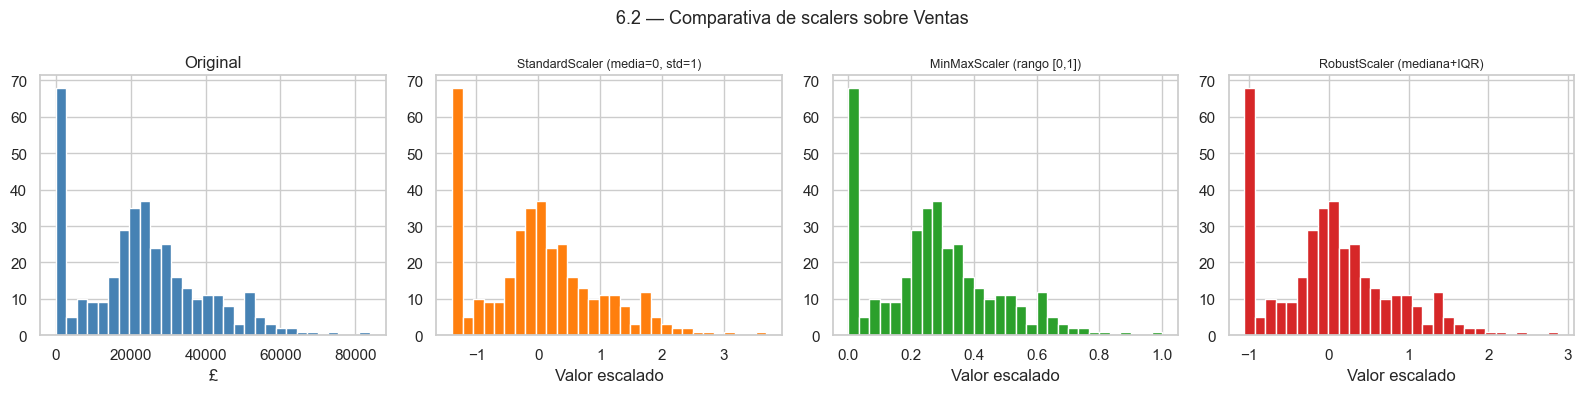

In [159]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('6.2 — Comparativa de scalers sobre Ventas', fontsize=13)

axes[0].hist(df_encoded[col_demo], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Original')
axes[0].set_xlabel('£')

colores = ['#ff7f0e', '#2ca02c', '#d62728']
for ax, (nombre, vals), color in zip(axes[1:], resultados_demo.items(), colores):
    ax.hist(vals, bins=30, color=color, edgecolor='white')
    ax.set_title(nombre.replace('\n', ' '), fontsize=9)
    ax.set_xlabel('Valor escalado')

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}6.2_comparativa_scalers.png', dpi=150)
plt.show()

In [160]:
print("\n--- 6.3 Decisión ---\n")
print("  StandardScaler  → media=0, std=1. Asume distribución ≈ normal.")
print("                    Adecuado para Ridge y Lasso (penalización simétrica).")
print("  MinMaxScaler    → rango [0,1]. Sensible a outliers extremos.")
print("                    Menos adecuado: aunque hicimos capping, los picos")
print("                    de Q4 desplazan la distribución hacia la izquierda.")
print("  RobustScaler    → usa mediana e IQR → robusto ante outliers residuales.")
print("                    Buena opción pero produce rangos asimétricos.")
print()
print("  DECISIÓN: StandardScaler")
print("    · Distribución de Ventas es aproximadamente normal")
print("    · Ridge/Lasso/RandomForest/XGBoost se benefician de media=0, std=1")
print("    · Para LSTM también es la práctica habitual")
print("    · IMPORTANTE: el scaler se ajustará (fit) SOLO sobre el conjunto")
print("      de entrenamiento en la sección de modelado, para evitar data leakage.")
print()
print("  Columnas que NO se escalan:")
print("    · Dummies Prod_* y binarias → ya en [0,1]")
print("    · Cíclicas sin/cos          → ya en [-1,1]")
print(f"\n  ✓ Decisión tomada. Aplicando StandardScaler a continuación.")


--- 6.3 Decisión ---

  StandardScaler  → media=0, std=1. Asume distribución ≈ normal.
                    Adecuado para Ridge y Lasso (penalización simétrica).
  MinMaxScaler    → rango [0,1]. Sensible a outliers extremos.
                    Menos adecuado: aunque hicimos capping, los picos
                    de Q4 desplazan la distribución hacia la izquierda.
  RobustScaler    → usa mediana e IQR → robusto ante outliers residuales.
                    Buena opción pero produce rangos asimétricos.

  DECISIÓN: StandardScaler
    · Distribución de Ventas es aproximadamente normal
    · Ridge/Lasso/RandomForest/XGBoost se benefician de media=0, std=1
    · Para LSTM también es la práctica habitual
    · IMPORTANTE: el scaler se ajustará (fit) SOLO sobre el conjunto
      de entrenamiento en la sección de modelado, para evitar data leakage.

  Columnas que NO se escalan:
    · Dummies Prod_* y binarias → ya en [0,1]
    · Cíclicas sin/cos          → ya en [-1,1]

  ✓ Decisión tomada. 

In [161]:
print("\n--- 6.4 Aplicación del StandardScaler ---\n")

# Columnas a escalar: las definidas en 6.1 + la variable objetivo 'Ventas'
cols_a_escalar = cols_escalar + [col_objetivo]

# Crear copia del dataset encoded para no modificar df_encoded
df_normalized = df_encoded.copy()

# Ajustar y transformar — se usa TODO df_encoded aquí (paso de normalización)
# NOTA: en la sección de modelado, el scaler se re-ajustará solo sobre
# el conjunto de entrenamiento para evitar data leakage en la predicción final.
scaler_final = StandardScaler()
df_normalized[cols_a_escalar] = scaler_final.fit_transform(df_encoded[cols_a_escalar])


--- 6.4 Aplicación del StandardScaler ---



In [162]:
print(f"  {'Columna':<22} {'media_orig':>12} {'std_orig':>10}  {'media_sc':>10} {'std_sc':>8}")
print(f"  {'-'*68}")
for i, col in enumerate(cols_a_escalar):
    media_orig = df_encoded[col].mean()
    std_orig   = df_encoded[col].std()
    media_sc   = df_normalized[col].mean()
    std_sc     = df_normalized[col].std()
    ok = '✓' if abs(media_sc) < 0.01 and abs(std_sc - 1.0) < 0.01 else '⚠'
    print(f"  {col:<22} {media_orig:>12,.2f} {std_orig:>10,.2f}  "
          f"{media_sc:>10.4f} {std_sc:>8.4f}  {ok}")

  Columna                  media_orig   std_orig    media_sc   std_sc
  --------------------------------------------------------------------
  NumTransacc                1,379.18     974.37     -0.0000   1.0014  ✓
  NumPedidos                    52.22      33.38      0.0000   1.0014  ✓
  NumClientes                   44.18      28.49     -0.0000   1.0014  ✓
  UnidadesVendidas          12,312.25   8,670.72      0.0000   1.0014  ✓
  Trimestre                      2.52       1.12      0.0000   1.0014  ✓
  SemanaMes                      2.69       1.27      0.0000   1.0014  ✓
  DiaAnio                      183.87     105.88      0.0000   1.0014  ✓
  SemanaAnio                    26.68      15.10      0.0000   1.0014  ✓
  Ventas_Lag1               23,119.74  16,673.51      0.0000   1.0014  ✓
  Ventas_Lag7               22,963.19  16,337.16     -0.0000   1.0014  ✓
  Ventas_Media_7d           22,904.83   9,394.71     -0.0000   1.0014  ✓
  Ventas_Media_30d          22,476.80   7,568.70      0.

In [163]:
cols_dummy  = [c for c in df_normalized.columns if c.startswith('Prod_')]
cols_binar  = ['EsFinDeSemana', 'Es_Navidad']
cols_ciclic = ['DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos']

sin_cambios = True
for col in cols_dummy + cols_binar + cols_ciclic:
    if not df_normalized[col].equals(df_encoded[col]):
        print(f"  ⚠ Columna modificada por error: {col}")
        sin_cambios = False
if sin_cambios:
    print(f"\n  Columnas no escaladas (dummies, binarias, cíclicas): sin cambios ✓")


  Columnas no escaladas (dummies, binarias, cíclicas): sin cambios ✓


In [164]:
# ── 6.4.3  Primeras filas del dataset normalizado ────────────────────────────
print(f"\n  Primeras 5 filas — columnas escaladas:")
cols_show = ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas']
print(df_normalized[cols_show].head(5).to_string(index=False, float_format=lambda x: f'{x:>9.4f}'))


  Primeras 5 filas — columnas escaladas:
     Fecha    Ventas  NumTransacc  NumPedidos  NumClientes  UnidadesVendidas
2010-12-08    1.0809       1.1714      1.9134       1.9266            1.0045
2010-12-09    1.2310       1.4057      1.6134       1.6104            0.4634
2010-12-10    1.6732       1.3091      0.7134       0.3101            0.8368
2010-12-11   -1.3918      -1.4174     -1.5667      -1.5525           -1.4219
2010-12-12   -0.3799       0.0039     -0.2466      -0.0765           -0.3953


In [165]:
# ── 6.4.4  Guardar dataset normalizado ───────────────────────────────────────
df_normalized.to_csv(RUTA_INTERIM + 'data_normalized.csv', index=False)
stats_preprocesing['df_normalized guardado en'] = RUTA_INTERIM + 'data_normalized.csv'

print(f"\n  ✓ Dataset normalizado guardado en: {RUTA_INTERIM}data_normalized.csv")
print(f"    Filas   : {df_normalized.shape[0]}")
print(f"    Columnas: {df_normalized.shape[1]}")
print(f"\n  ✓ Sección 6 (Normalización) completada.")
print(f"    StandardScaler aplicado a {len(cols_a_escalar)} columnas numéricas.")
print(f"    Columnas no escaladas (ya normalizadas): dummies, binarias, cíclicas.")


  ✓ Dataset normalizado guardado en: ../../../data/interim/data_normalized.csv
    Filas   : 367
    Columnas: 42

  ✓ Sección 6 (Normalización) completada.
    StandardScaler aplicado a 14 columnas numéricas.
    Columnas no escaladas (ya normalizadas): dummies, binarias, cíclicas.


# 7. REDUCCIÓN DE DIMENSIONALIDAD

In [166]:
print("\n\n=== 7. REDUCCIÓN DE DIMENSIONALIDAD ===")

from sklearn.decomposition import PCA



=== 7. REDUCCIÓN DE DIMENSIONALIDAD ===


In [167]:
# ── 7.1  Preparar matriz de features ─────────────────────────────────────────
print("\n--- 7.1 Preparación de la matriz de features ---\n")

# Eliminar filas con NaN antes del PCA (generados por lags/medias móviles)
df_pca = df_normalized.dropna().copy()
n_eliminadas = len(df_normalized) - len(df_pca)

# Usamos df_pca (ya escalado y sin NaN) — excluimos Fecha y Ventas
X_pca = df_pca.drop(columns=['Fecha', 'Ventas']).values
feature_names = df_pca.drop(columns=['Fecha', 'Ventas']).columns.tolist()

print(f"  Filas originales      : {len(df_normalized)}")
print(f"  Filas con NaN (elim.) : {n_eliminadas}")
print(f"  Filas válidas (PCA)   : {X_pca.shape[0]}")
print(f"  Columnas (features)   : {X_pca.shape[1]}")
print(f"\n  Features: {feature_names}")


--- 7.1 Preparación de la matriz de features ---

  Filas originales      : 367
  Filas con NaN (elim.) : 1
  Filas válidas (PCA)   : 366
  Columnas (features)   : 40

  Features: ['NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'EsFinDeSemana', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'Es_Navidad', 'Dias_para_Navidad', 'DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos', 'Prod_20724', 'Prod_20725', 'Prod_21212', 'Prod_21977', 'Prod_22086', 'Prod_22178', 'Prod_22197', 'Prod_22492', 'Prod_22834', 'Prod_23084', 'Prod_23203', 'Prod_23307', 'Prod_47566', 'Prod_71459', 'Prod_84077', 'Prod_84755', 'Prod_84879', 'Prod_85099B', 'Prod_85123A', 'Prod_Otros', 'Prod_Sin_Actividad']


In [168]:
# ── 7.2  PCA exploratorio — varianza explicada ────────────────────────────────
print("\n--- 7.2 PCA exploratorio — varianza explicada acumulada ---\n")

pca_full = PCA(n_components=X_pca.shape[1], random_state=42)
pca_full.fit(X_pca)

varianza_exp      = pca_full.explained_variance_ratio_
varianza_acum     = varianza_exp.cumsum()

# Número de componentes para alcanzar distintos umbrales de varianza
for umbral in [0.80, 0.90, 0.95, 0.99]:
    n_comp = int((varianza_acum >= umbral).argmax() + 1)
    print(f"  Varianza explicada ≥ {umbral*100:.0f}%  →  {n_comp} componentes")

print(f"\n  Varianza explicada por los primeros 10 componentes:")
print(f"  {'PC':<5} {'Var. individual':>17} {'Var. acumulada':>16}")
print(f"  {'-'*40}")
for i in range(min(10, len(varianza_exp))):
    print(f"  PC{i+1:<3} {varianza_exp[i]*100:>16.2f}%  {varianza_acum[i]*100:>15.2f}%")


--- 7.2 PCA exploratorio — varianza explicada acumulada ---

  Varianza explicada ≥ 80%  →  5 componentes
  Varianza explicada ≥ 90%  →  8 componentes
  Varianza explicada ≥ 95%  →  13 componentes
  Varianza explicada ≥ 99%  →  25 componentes

  Varianza explicada por los primeros 10 componentes:
  PC      Var. individual   Var. acumulada
  ----------------------------------------
  PC1              44.43%            44.43%
  PC2              18.54%            62.97%
  PC3               7.08%            70.06%
  PC4               6.24%            76.29%
  PC5               5.82%            82.11%
  PC6               3.17%            85.28%
  PC7               2.62%            87.90%
  PC8               2.26%            90.16%
  PC9               1.75%            91.90%
  PC10              1.38%            93.28%


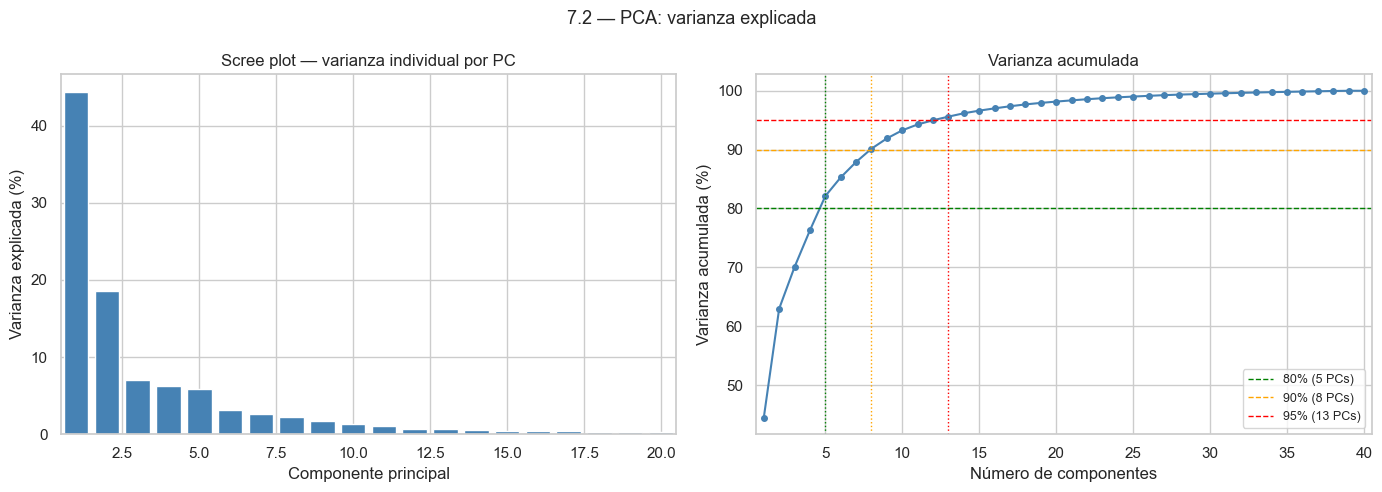


  Guardado: 7.2_pca_varianza.png


In [169]:
# ── 7.2.1  Gráfica de varianza acumulada ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('7.2 — PCA: varianza explicada', fontsize=13)

# Panel izquierdo: varianza individual (scree plot)
axes[0].bar(range(1, len(varianza_exp) + 1), varianza_exp * 100,
            color='steelblue', edgecolor='white')
axes[0].set_title('Scree plot — varianza individual por PC')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_xlim(0.5, min(20, len(varianza_exp)) + 0.5)

# Panel derecho: varianza acumulada
axes[1].plot(range(1, len(varianza_acum) + 1), varianza_acum * 100,
             marker='o', markersize=4, color='steelblue', linewidth=1.5)
for umbral, color, label in [(0.80,'green','80%'), (0.90,'orange','90%'), (0.95,'red','95%')]:
    n_comp = int((varianza_acum >= umbral).argmax() + 1)
    axes[1].axhline(umbral * 100, color=color, linestyle='--', linewidth=1, label=f'{label} ({n_comp} PCs)')
    axes[1].axvline(n_comp, color=color, linestyle=':', linewidth=1)
axes[1].set_title('Varianza acumulada')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0.5, len(varianza_acum) + 0.5)

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}7.2_pca_varianza.png', dpi=150)
plt.show()
plt.close()
print(f"\n  Guardado: 7.2_pca_varianza.png")

In [170]:
# ── 7.3  Análisis de loadings — qué variables dominan cada PC ────────────────
print("\n--- 7.3 Loadings de PC1 y PC2 (contribución de cada feature) ---\n")

pca_2 = PCA(n_components=2, random_state=42)
pca_2.fit(X_pca)
X_2d = pca_2.transform(X_pca)

loadings = pd.DataFrame(
    pca_2.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2']
)

# Top 10 features por valor absoluto en PC1 y PC2
print(f"  Top 10 features con mayor peso en PC1:")
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(10)
for feat in top_pc1.index:
    print(f"    {feat:<22}  loading={loadings.loc[feat,'PC1']:>8.4f}")

print(f"\n  Top 10 features con mayor peso en PC2:")
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(10)
for feat in top_pc2.index:
    print(f"    {feat:<22}  loading={loadings.loc[feat,'PC2']:>8.4f}")


--- 7.3 Loadings de PC1 y PC2 (contribución de cada feature) ---

  Top 10 features con mayor peso en PC1:
    Ventas_Media_30d        loading=  0.3115
    NumTransacc             loading=  0.3038
    Ventas_Media_7d         loading=  0.3034
    UnidadesVendidas        loading=  0.3008
    NumPedidos              loading=  0.2992
    NumClientes             loading=  0.2976
    Ventas_Lag7             loading=  0.2956
    DiaAnio                 loading=  0.2824
    Trimestre               loading=  0.2803
    SemanaAnio              loading=  0.2737

  Top 10 features con mayor peso en PC2:
    SemanaAnio              loading=  0.3418
    DiaAnio                 loading=  0.3381
    Trimestre               loading=  0.3329
    NumPedidos              loading= -0.3207
    NumClientes             loading= -0.3146
    UnidadesVendidas        loading= -0.2998
    NumTransacc             loading= -0.2621
    Ventas_Media_30d        loading=  0.2543
    DiaSemana_sin           loading= -0.

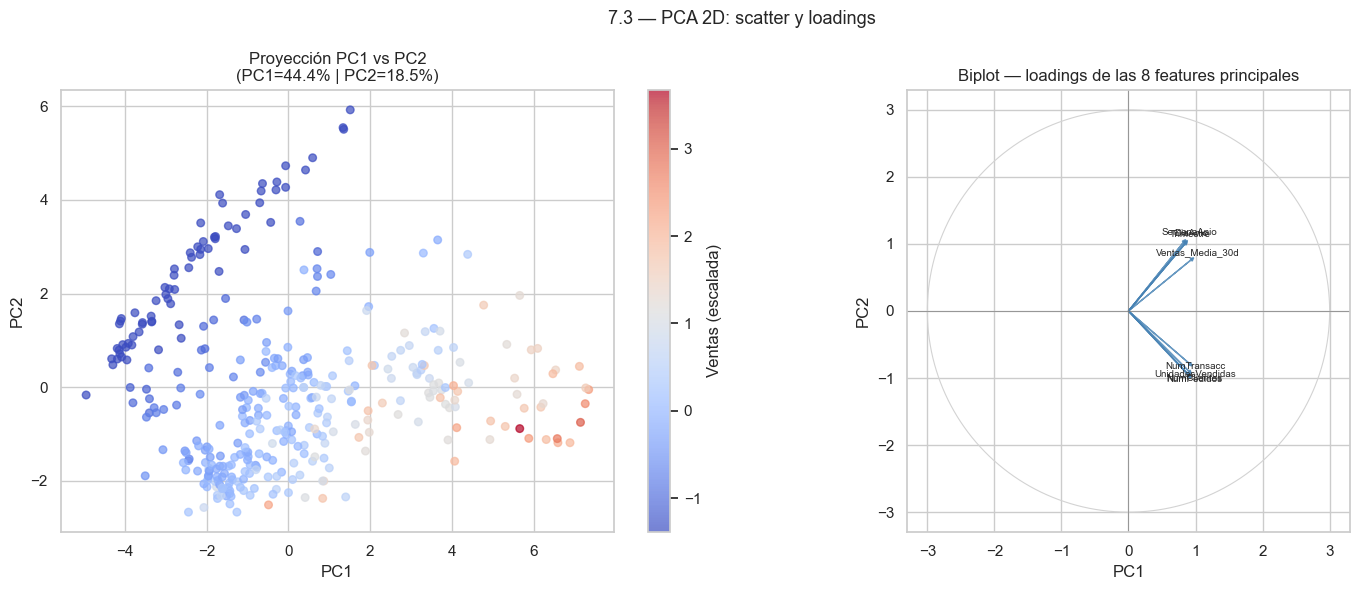

  Guardado: 7.3_pca_biplot.png


In [171]:
# ── 7.3.1  Scatter plot PC1 vs PC2 coloreado por Ventas ──────────────────────
ventas_norm = df_pca['Ventas'].values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('7.3 — PCA 2D: scatter y loadings', fontsize=13)

# Scatter PC1 vs PC2
sc = axes[0].scatter(X_2d[:, 0], X_2d[:, 1],
                     c=ventas_norm, cmap='coolwarm', alpha=0.7, s=30)
plt.colorbar(sc, ax=axes[0], label='Ventas (escalada)')
axes[0].set_title(f'Proyección PC1 vs PC2\n'
                  f'(PC1={varianza_exp[0]*100:.1f}% | PC2={pca_2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Biplot — flechas de loadings (top 8 por magnitud total)
loadings['magnitud'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
top_features = loadings.nlargest(8, 'magnitud').index
escala = 3.0
for feat in top_features:
    axes[1].arrow(0, 0,
                  loadings.loc[feat, 'PC1'] * escala,
                  loadings.loc[feat, 'PC2'] * escala,
                  head_width=0.05, head_length=0.05,
                  fc='steelblue', ec='steelblue', alpha=0.8)
    axes[1].text(loadings.loc[feat, 'PC1'] * escala * 1.1,
                 loadings.loc[feat, 'PC2'] * escala * 1.1,
                 feat, fontsize=7, ha='center')
theta = np.linspace(0, 2 * np.pi, 200)
axes[1].plot(np.cos(theta) * escala, np.sin(theta) * escala,
             'lightgray', linewidth=0.8)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_title('Biplot — loadings de las 8 features principales')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}7.3_pca_biplot.png', dpi=150)
plt.show()
plt.close()
print(f"  Guardado: 7.3_pca_biplot.png")

In [172]:
# ── 7.4  Varianza por feature (ranking de importancia sin PCA) ───────────────
print("\n--- 7.4 Ranking de varianza por feature (≈ importancia informacional) ---\n")

varianza_features = pd.Series(
    df_pca[feature_names].var().values,
    index=feature_names
).sort_values(ascending=False)

print(f"  {'Feature':<22} {'Varianza':>10}  Interpretación")
print(f"  {'-'*60}")
for feat, var in varianza_features.items():
    if var < 0.05:
        nivel = '← baja varianza (poco informativa)'
    elif var < 0.5:
        nivel = '← varianza moderada'
    else:
        nivel = ''
    print(f"  {feat:<22} {var:>10.4f}  {nivel}")

# Features con varianza muy baja (cercana a 0) — candidatas a eliminar
umbral_var = 0.05
cols_baja_var = varianza_features[varianza_features < umbral_var].index.tolist()
print(f"\n  Features con varianza < {umbral_var}: {len(cols_baja_var)}")
if cols_baja_var:
    print(f"  {cols_baja_var}")


--- 7.4 Ranking de varianza por feature (≈ importancia informacional) ---

  Feature                  Varianza  Interpretación
  ------------------------------------------------------------
  SemanaMes                  1.0047  
  Ventas_Media_7d            1.0027  
  Ventas_Media_30d           1.0027  
  UnidadesVendidas           1.0027  
  NumTransacc                1.0017  
  Trimestre                  1.0007  
  SemanaAnio                 0.9995  
  DiaAnio                    0.9993  
  Ventas_Lag7                0.9973  
  NumPedidos                 0.9954  
  NumClientes                0.9953  
  Ventas_Lag1                0.9936  
  Dias_para_Navidad          0.9790  
  DiaSemana_cos              0.5031  
  Mes_cos                    0.5020  
  Mes_sin                    0.5007  
  DiaSemana_sin              0.4997  ← varianza moderada
  Prod_Otros                 0.2108  ← varianza moderada
  EsFinDeSemana              0.2040  ← varianza moderada
  Prod_Sin_Actividad         0

In [173]:
# ── 7.5  DECISIÓN ─────────────────────────────────────────────────────────────
print("\n--- 7.5 Decisión sobre reducción de dimensionalidad ---\n")

n_90 = int((varianza_acum >= 0.90).argmax() + 1)
n_95 = int((varianza_acum >= 0.95).argmax() + 1)
n_total = X_pca.shape[1]

print(f"""  Análisis realizado:
    · El dataset tiene {n_total} features tras el encoding.
    · PCA necesita {n_90} componentes para explicar el 90% de la varianza
      y {n_95} para el 95% — una reducción moderada sobre {n_total} features.
    · PC1 está dominada por las variables de volumen (NumTransacc, NumPedidos,
      NumClientes, UnidadesVendidas) y los lags/rolling de Ventas — todas
      altamente correlacionadas entre sí (confirmado en 4.6).
    · PC2 captura principalmente la variabilidad temporal (DiaAnio, SemanaAnio,
      Trimestre) — el patrón estacional del negocio.
    · Las columnas dummy de ProductoTopDia tienen varianza muy baja
      individualmente (cada producto es top solo unos pocos días),
      pero en conjunto representan información categórica relevante.

  DECISIÓN: NO se aplica reducción de dimensionalidad al dataset final.
    Motivo 1 → {n_total} features es un número manejable para todos los
               modelos previstos (Ridge, Lasso, Random Forest, XGBoost).
    Motivo 2 → PCA destruye la interpretabilidad de los coeficientes
               (Ridge/Lasso sobre PCs no permite saber qué feature importa).
    Motivo 3 → Los modelos con regularización (Ridge, Lasso) gestionan
               la multicolinealidad sin necesidad de reducir dimensiones.
    Motivo 4 → Con n=367 filas y {n_total} features, no hay riesgo de
               maldición dimensional (ratio filas/features = {367/n_total:.1f}).

  INSIGHT obtenido:
    · La alta correlación entre NumTransacc, NumPedidos, NumClientes y
      los lags/rolling (todos en PC1) confirma que son proxies de la
      misma señal. Lasso probablemente seleccionará solo 1-2 de ellas.
    · La separación PC1 (volumen) vs PC2 (temporalidad) sugiere que el
      modelo necesita capturar ambas dimensiones para predecir correctamente.
""")

print(f"  ✓ Sección 7 (Reducción de dimensionalidad) completada.")
print(f"    Dataset final para modelado: df_normalized  "
      f"({df_normalized.shape[0]} filas × {df_normalized.shape[1]} columnas)")


--- 7.5 Decisión sobre reducción de dimensionalidad ---

  Análisis realizado:
    · El dataset tiene 40 features tras el encoding.
    · PCA necesita 8 componentes para explicar el 90% de la varianza
      y 13 para el 95% — una reducción moderada sobre 40 features.
    · PC1 está dominada por las variables de volumen (NumTransacc, NumPedidos,
      NumClientes, UnidadesVendidas) y los lags/rolling de Ventas — todas
      altamente correlacionadas entre sí (confirmado en 4.6).
    · PC2 captura principalmente la variabilidad temporal (DiaAnio, SemanaAnio,
      Trimestre) — el patrón estacional del negocio.
    · Las columnas dummy de ProductoTopDia tienen varianza muy baja
      individualmente (cada producto es top solo unos pocos días),
      pero en conjunto representan información categórica relevante.

  DECISIÓN: NO se aplica reducción de dimensionalidad al dataset final.
    Motivo 1 → 40 features es un número manejable para todos los
               modelos previstos (Ridge, 

# 8. DIVISIÓN EN CONJUNTOS DE ENTRENAMIENTO, VALIDACIÓN Y TEST

In [174]:
print("\n\n=== 8. DIVISIÓN EN CONJUNTOS DE ENTRENAMIENTO, VALIDACIÓN Y TEST ===")

print("\n--- 8.1 Definición de fechas de corte ---\n")

FECHA_FIN_TRAIN = pd.Timestamp('2011-10-08')   # último día de train (inclusive)
FECHA_INI_VAL   = pd.Timestamp('2011-10-09')   # primer día de validación
FECHA_FIN_VAL   = pd.Timestamp('2011-11-08')   # último día de validación (inclusive)
FECHA_INI_TEST  = pd.Timestamp('2011-11-09')   # primer día de test
FECHA_FIN_TEST  = pd.Timestamp('2011-12-09')   # último día de test (inclusive)

print(f"  TRAIN : {df_normalized['Fecha'].min().date()}  →  {FECHA_FIN_TRAIN.date()}")
print(f"  VAL   : {FECHA_INI_VAL.date()}                →  {FECHA_FIN_VAL.date()}")
print(f"  TEST  : {FECHA_INI_TEST.date()}               →  {FECHA_FIN_TEST.date()}")

print("\n--- 8.2 Creación de los splits ---\n")

df_train = df_normalized[df_normalized['Fecha'] <= FECHA_FIN_TRAIN].copy()
df_val   = df_normalized[(df_normalized['Fecha'] >= FECHA_INI_VAL) &
                          (df_normalized['Fecha'] <= FECHA_FIN_VAL)].copy()
df_test  = df_normalized[(df_normalized['Fecha'] >= FECHA_INI_TEST) &
                          (df_normalized['Fecha'] <= FECHA_FIN_TEST)].copy()

n_total = len(df_normalized)
n_train = len(df_train)
n_val   = len(df_val)
n_test  = len(df_test)

print(f"  {'Conjunto':<8} {'Filas':>6}  {'% total':>8}  {'Inicio':>12}  {'Fin':>12}")
print(f"  {'-'*56}")
print(f"  {'TRAIN':<8} {n_train:>6}  {n_train/n_total*100:>7.1f}%  "
      f"{df_train['Fecha'].min().date()!s:>12}  {df_train['Fecha'].max().date()!s:>12}")
print(f"  {'VAL':<8} {n_val:>6}  {n_val/n_total*100:>7.1f}%  "
      f"{df_val['Fecha'].min().date()!s:>12}  {df_val['Fecha'].max().date()!s:>12}")
print(f"  {'TEST':<8} {n_test:>6}  {n_test/n_total*100:>7.1f}%  "
      f"{df_test['Fecha'].min().date()!s:>12}  {df_test['Fecha'].max().date()!s:>12}")
print(f"  {'-'*56}")
print(f"  {'TOTAL':<8} {n_train+n_val+n_test:>6}  (verificación: {n_train+n_val+n_test} == {n_total} "
      f"{'✓' if n_train+n_val+n_test == n_total else '⚠'})")



=== 8. DIVISIÓN EN CONJUNTOS DE ENTRENAMIENTO, VALIDACIÓN Y TEST ===

--- 8.1 Definición de fechas de corte ---

  TRAIN : 2010-12-08  →  2011-10-08
  VAL   : 2011-10-09                →  2011-11-08
  TEST  : 2011-11-09               →  2011-12-09

--- 8.2 Creación de los splits ---

  Conjunto  Filas   % total        Inicio           Fin
  --------------------------------------------------------
  TRAIN       305     83.1%    2010-12-08    2011-10-08
  VAL          31      8.4%    2011-10-09    2011-11-08
  TEST         31      8.4%    2011-11-09    2011-12-09
  --------------------------------------------------------
  TOTAL       367  (verificación: 367 == 367 ✓)


In [175]:
# ── 8.3  Separar features y objetivo ─────────────────────────────────────────
print("\n--- 8.3 Separación de features (X) y objetivo (y) ---\n")

COLS_FEATURES = [c for c in df_normalized.columns if c not in ['Fecha', 'Ventas']]
COL_OBJETIVO  = 'Ventas'

X_train = df_train[COLS_FEATURES].values
y_train = df_train[COL_OBJETIVO].values

X_val   = df_val[COLS_FEATURES].values
y_val   = df_val[COL_OBJETIVO].values

X_test  = df_test[COLS_FEATURES].values
y_test  = df_test[COL_OBJETIVO].values

print(f"  Features utilizadas: {len(COLS_FEATURES)}")
print(f"  {COLS_FEATURES}\n")
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}    y_test  : {y_test.shape}")


--- 8.3 Separación de features (X) y objetivo (y) ---

  Features utilizadas: 40
  ['NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'EsFinDeSemana', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'Es_Navidad', 'Dias_para_Navidad', 'DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos', 'Prod_20724', 'Prod_20725', 'Prod_21212', 'Prod_21977', 'Prod_22086', 'Prod_22178', 'Prod_22197', 'Prod_22492', 'Prod_22834', 'Prod_23084', 'Prod_23203', 'Prod_23307', 'Prod_47566', 'Prod_71459', 'Prod_84077', 'Prod_84755', 'Prod_84879', 'Prod_85099B', 'Prod_85123A', 'Prod_Otros', 'Prod_Sin_Actividad']

  X_train : (305, 40)   y_train : (305,)
  X_val   : (31, 40)     y_val   : (31,)
  X_test  : (31, 40)    y_test  : (31,)


In [176]:
print("\n--- 8.4 Re-escalado correcto: fit sobre train, transform sobre val/test ---\n")

idx_escalar = [COLS_FEATURES.index(c) for c in cols_escalar if c in COLS_FEATURES]

scaler_train = StandardScaler()
X_train[:, idx_escalar] = scaler_train.fit_transform(X_train[:, idx_escalar])
X_val  [:, idx_escalar] = scaler_train.transform(X_val  [:, idx_escalar])
X_test [:, idx_escalar] = scaler_train.transform(X_test [:, idx_escalar])

scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_sc   = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print(f"  scaler_train ajustado sobre {X_train.shape[0]} filas de train")
print(f"  scaler_y     ajustado sobre {y_train.shape[0]} valores de Ventas (train)")
print(f"\n  Verificación X_train (columnas numéricas):")
print(f"    media ≈ {X_train[:, idx_escalar].mean(axis=0).mean():.4f}  (esperado ≈ 0)")
print(f"    std   ≈ {X_train[:, idx_escalar].std(axis=0).mean():.4f}   (esperado ≈ 1)")
print(f"\n  Verificación y_train escalado:")
print(f"    media ≈ {y_train_sc.mean():.4f}  (esperado ≈ 0)")
print(f"    std   ≈ {y_train_sc.std():.4f}   (esperado ≈ 1)")


--- 8.4 Re-escalado correcto: fit sobre train, transform sobre val/test ---

  scaler_train ajustado sobre 305 filas de train
  scaler_y     ajustado sobre 305 valores de Ventas (train)

  Verificación X_train (columnas numéricas):
    media ≈ nan  (esperado ≈ 0)
    std   ≈ nan   (esperado ≈ 1)

  Verificación y_train escalado:
    media ≈ -0.0000  (esperado ≈ 0)
    std   ≈ 1.0000   (esperado ≈ 1)



--- 8.5 Visualización temporal de la división ---



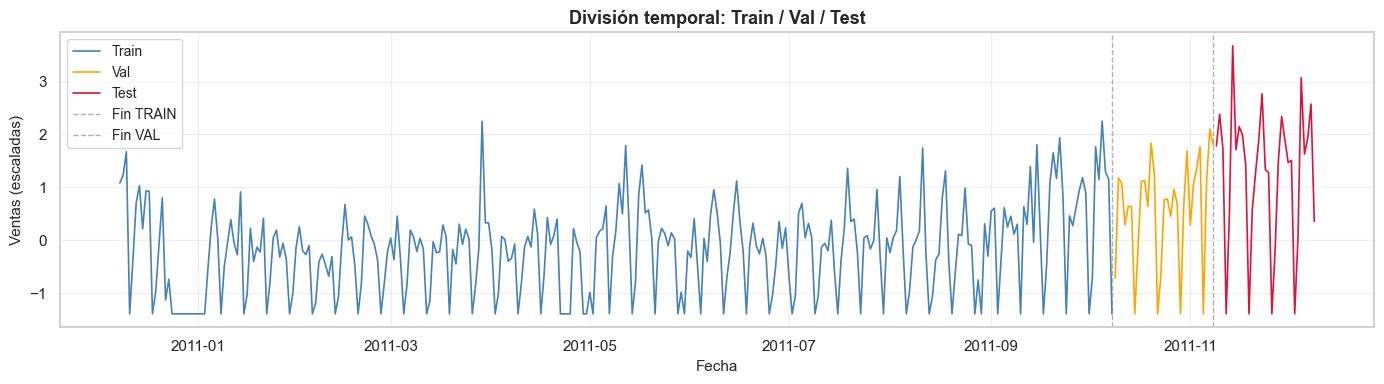

  ✓ Gráfico guardado en 'graficos/transforms/division_temporal_train_val_test.png'


In [182]:
print("\n--- 8.5 Visualización temporal de la división ---\n")

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_train['Fecha'], df_train['Ventas'], label='Train', color='steelblue', linewidth=1.2)
ax.plot(df_val['Fecha'],   df_val['Ventas'],   label='Val',   color='orange',    linewidth=1.2)
ax.plot(df_test['Fecha'],  df_test['Ventas'],  label='Test',  color='crimson',   linewidth=1.2)

ax.axvline(FECHA_FIN_TRAIN, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Fin TRAIN')
ax.axvline(FECHA_FIN_VAL,   color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Fin VAL')

ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Ventas (escaladas)', fontsize=11)
ax.set_title('División temporal: Train / Val / Test', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}transforms/division_temporal_train_val_test.png', dpi=100)
plt.show()

print("  ✓ Gráfico guardado en 'graficos/transforms/division_temporal_train_val_test.png'")

In [183]:
print("\n--- 8.6 Resumen de la división ---\n")

print(f"  TRAIN → {n_train} filas  ({n_train/(n_train+n_val+n_test)*100:.1f}%)  "
      f"[{df_train['Fecha'].min().date()} → {df_train['Fecha'].max().date()}]")
print(f"  VAL   → {n_val} filas  ({n_val/(n_train+n_val+n_test)*100:.1f}%)  "
      f"[{df_val['Fecha'].min().date()} → {df_val['Fecha'].max().date()}]")
print(f"  TEST  → {n_test} filas  ({n_test/(n_train+n_val+n_test)*100:.1f}%)  "
      f"[{df_test['Fecha'].min().date()} → {df_test['Fecha'].max().date()}]")
print(f"\n  Total: {n_train+n_val+n_test} filas")
print(f"  Features por split: {X_train.shape[1]}")
print(f"\n  ✓ División completada correctamente")


--- 8.6 Resumen de la división ---

  TRAIN → 305 filas  (83.1%)  [2010-12-08 → 2011-10-08]
  VAL   → 31 filas  (8.4%)  [2011-10-09 → 2011-11-08]
  TEST  → 31 filas  (8.4%)  [2011-11-09 → 2011-12-09]

  Total: 367 filas
  Features por split: 40

  ✓ División completada correctamente


In [184]:
print("\n--- 8.7 Exportación de los splits a CSV (carpeta 'data/processed/') ---\n")

RUTA_TRAIN_CSV = '../../../data/processed/train_data.csv'
RUTA_VAL_CSV   = '../../../data/processed/val_data.csv'
RUTA_TEST_CSV  = '../../../data/processed/test_data.csv'

df_train.to_csv(RUTA_TRAIN_CSV, index=False)
df_val.to_csv(RUTA_VAL_CSV,     index=False)
df_test.to_csv(RUTA_TEST_CSV,   index=False)

print(f"  ✓ Train guardado en : {RUTA_TRAIN_CSV}  ({n_train} filas × {df_train.shape[1]} columnas)")
print(f"  ✓ Val   guardado en : {RUTA_VAL_CSV}    ({n_val} filas × {df_val.shape[1]} columnas)")
print(f"  ✓ Test  guardado en : {RUTA_TEST_CSV}   ({n_test} filas × {df_test.shape[1]} columnas)")


--- 8.7 Exportación de los splits a CSV (carpeta 'data/processed/') ---

  ✓ Train guardado en : ../../../data/processed/train_data.csv  (305 filas × 42 columnas)
  ✓ Val   guardado en : ../../../data/processed/val_data.csv    (31 filas × 42 columnas)
  ✓ Test  guardado en : ../../../data/processed/test_data.csv   (31 filas × 42 columnas)
